In [126]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import re
from collections import defaultdict

In [65]:
emotions_col = ['Wonder', 'Transcendence', 'Nostalgia',
                'Tenderness', 'Peacefulness', 'Joy',
                'Sadness', 'Power','Tension']

In [66]:
# Parse the textfiles of the results into Dataframes
def decode_results(results_file, emotions_col = emotions_col):

    rows = []
 
    with open(results_file, "r") as f:
        
        for line in f:
            line = line.strip()
            
            row = {}
            for emotion in emotions_col:
                pattern = rf"-\s*{emotion}:\s*(\d+)"
                match = re.search(pattern, line)
                row[emotion] = int(match.group(1)) if match else None
    
            rows.append(row)

    df = pd.DataFrame(rows, columns=emotions_col)
    df.index += 1
    
    return df

### Load results and compute metrics 

In [67]:
# Import the Datasets
test_recoded_df = pd.read_csv('../data/test.csv')
test_og_df = pd.read_csv('../data/test_og.csv')

# Music Flamingo :
# Base model predictions
MF_base_df = pd.read_csv('../results/MF_test_results.csv',
                         na_values='None')
MF_base_single = pd.read_csv('../results/MF_single_emo.csv',
                         na_values='None')
MF_base_random = pd.read_csv('../results/MF_randomized_results.csv',
                         na_values='None')
MF_base_og = pd.read_csv('../results/MF_og_test.csv',
                         na_values='None')

# Finetuned model predictions
MF_finetuned_df = pd.read_csv('../results/MF_finetuned_results.csv',
                      na_values='None')

# Voxtral :
# Base model predictions
Voxtral_base_df = pd.read_csv('../results/Voxtral_test_results.csv',
                      na_values='None')
Voxtral_base_single = pd.read_csv('../results/Voxtral_single_emo.csv',
                      na_values='None')
Voxtral_base_random = pd.read_csv('../results/Voxtral_randomized_results.csv',
                      na_values='None')
Voxtral_base_og = pd.read_csv('../results/Voxtral_og_test.csv',
                      na_values='None')

# Finetuned model predictions
Voxtral_finetuned_df = pd.read_csv('../results/Voxtral_finetuned_results.csv',
                      na_values='None')

In [68]:
def compute_metrics(model_pred, test_data = test_recoded_df, og_data = False):
    """
    Compute different errors for the results

    Args:
        model_pred : Dataframe of the predictions
        test_data : Dataframe of the true values
        og_data (bool) : True if the data was computed for the original (0-100) scores
    """

    # Define lists for each error type
    emo_mae = []
    emo_rmse = []
    emo_kappa = []
    emo_nmae = [] 
    missing_values = []

    # Metric computation for each emotion
    for emo in emotions_col:

        # Mask the missing values
        mask = model_pred[emo].notna()
        actual = test_data.loc[mask, emo]
        predicted = model_pred.loc[mask, emo]

        # Compute Mean Absolute error
        mae = mean_absolute_error(actual, predicted)
        emo_mae.append(round(mae, 3))

        # Compute Mean Absolute Error, normalized on the max error
        nmae = mae/4 if og_data == False else mae/100
        emo_nmae.append(round(nmae,3))

        # Compute Root Mean Squarred error
        nrmse = root_mean_squared_error(actual,predicted)
        nrmse = nrmse/4 if og_data == False else nrmse/100
        emo_rmse.append(round(nrmse, 3))

        # Compute Cohen Kappa
        if og_data == False:
            kappa = cohen_kappa_score(actual,predicted, weights='quadratic')
            emo_kappa.append(round(kappa, 3))
        
        # Count the missing values
        missing_values.append(int(model_pred[emo].isna().sum()))

    # Save the metrics in dict
    emo_metrics = {'mae': emo_mae,
                   'nmae': emo_nmae,
                   'nrmse': emo_rmse,
                   'kappa': emo_kappa if len(emo_kappa) > 0 else None,
                   'missing values': missing_values}
    
    # Filter and drop the missing values
    mask = model_pred[emotions_col].notna()
    actual = test_data[emotions_col].where(mask).dropna()
    predicted = model_pred[emotions_col].where(mask).dropna()

    # Ravel all the data
    actual = actual.values.ravel()
    predicted = predicted.values.ravel()

    # Global Metrics
    # Compute global MAE
    glob_mae = mean_absolute_error(actual, predicted)
    # Compute global NMAE
    glob_nmae = glob_mae/4 if og_data == False else glob_mae/100
    # Compute global NRMSE
    glob_nrmse = root_mean_squared_error(actual,predicted)/4 if og_data == False else root_mean_squared_error(actual,predicted)/100
    # Compute global Kappa
    glob_kappa = round(cohen_kappa_score(actual,predicted, weights='quadratic'),3) if og_data == False else None #round(np.mean(emo_kappa),3)

    glob_metrics = {'mae': round(glob_mae,3),
                    'nmae': round(glob_nmae,3),
                    'nrmse': round(glob_nrmse,3),
                    'kappa': glob_kappa,
                    }

    return  emo_metrics, glob_metrics

### Music flamingo Metrics

In [69]:
mf_base_metrics = compute_metrics(MF_base_df)
mf_base_metrics

({'mae': [0.965, 0.991, 1.583, 0.957, 1.061, 1.574, 0.757, 1.009, 0.92],
  'nmae': [0.241, 0.248, 0.396, 0.239, 0.265, 0.393, 0.189, 0.252, 0.23],
  'nrmse': [0.31, 0.33, 0.49, 0.335, 0.326, 0.485, 0.301, 0.33, 0.333],
  'kappa': [0.095, 0.245, 0.108, 0.476, 0.472, 0.314, 0.278, 0.454, 0.324],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 2]},
 {'mae': 1.088, 'nmae': 0.272, 'nrmse': 0.367, 'kappa': 0.367})

In [70]:
mf_og_metrics = compute_metrics(MF_base_og, test_og_df, og_data=True)
mf_og_metrics

({'mae': [48.881,
   51.192,
   30.611,
   32.485,
   26.989,
   21.146,
   18.206,
   26.911,
   21.05],
  'nmae': [0.489, 0.512, 0.306, 0.325, 0.27, 0.211, 0.182, 0.269, 0.21],
  'nrmse': [0.513, 0.539, 0.34, 0.366, 0.328, 0.259, 0.251, 0.326, 0.268],
  'kappa': None,
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 1]},
 {'mae': 30.959, 'nmae': 0.31, 'nrmse': 0.369, 'kappa': None})

In [71]:
mf_random_metrics = compute_metrics(MF_base_random)
mf_random_metrics

({'mae': [0.887, 0.939, 1.33, 1.018, 1.287, 1.53, 0.93, 1.026, 0.922],
  'nmae': [0.222, 0.235, 0.333, 0.254, 0.322, 0.383, 0.233, 0.257, 0.23],
  'nrmse': [0.293, 0.32, 0.428, 0.355, 0.412, 0.466, 0.326, 0.333, 0.32],
  'kappa': [0.271, 0.119, 0.195, 0.285, 0.266, 0.322, 0.19, 0.486, 0.382],
  'missing values': [0, 0, 0, 1, 0, 0, 0, 0, 0]},
 {'mae': 1.096, 'nmae': 0.274, 'nrmse': 0.366, 'kappa': 0.328})

In [72]:
mf_single_emo_metrics = compute_metrics(MF_base_single)
mf_single_emo_metrics

({'mae': [0.861, 0.887, 1.139, 0.93, 0.93, 0.991, 1.2, 0.948, 1.104],
  'nmae': [0.215, 0.222, 0.285, 0.233, 0.233, 0.248, 0.3, 0.237, 0.276],
  'nrmse': [0.285, 0.286, 0.334, 0.298, 0.305, 0.304, 0.352, 0.294, 0.329],
  'kappa': [0.187, 0.169, 0.175, 0.467, 0.523, 0.449, 0.161, 0.407, 0.183],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 0.999, 'nmae': 0.25, 'nrmse': 0.31, 'kappa': 0.359})

In [73]:
mf_finetuned_metrics = compute_metrics(MF_finetuned_df)
mf_finetuned_metrics

({'mae': [1.096, 0.73, 1.565, 1.113, 1.383, 1.026, 0.87, 0.991, 1.0],
  'nmae': [0.274, 0.183, 0.391, 0.278, 0.346, 0.257, 0.217, 0.248, 0.25],
  'nrmse': [0.361, 0.268, 0.485, 0.372, 0.439, 0.354, 0.344, 0.323, 0.327],
  'kappa': [0.0, 0.0, 0.0, 0.012, 0.011, 0.237, 0.005, 0.455, 0.24],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 1.086, 'nmae': 0.271, 'nrmse': 0.369, 'kappa': 0.315})

### Voxtral predictions metrics

In [74]:
voxtral_base_metrics = compute_metrics(Voxtral_base_df)
voxtral_base_metrics

({'mae': [1.026, 0.922, 1.191, 1.139, 1.148, 2.165, 1.252, 1.722, 1.062],
  'nmae': [0.257, 0.23, 0.298, 0.285, 0.287, 0.541, 0.313, 0.43, 0.265],
  'nrmse': [0.325, 0.291, 0.366, 0.359, 0.4, 0.629, 0.412, 0.542, 0.366],
  'kappa': [0.16, 0.203, 0.143, 0.234, 0.303, 0.097, 0.223, 0.114, 0.273],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 2]},
 {'mae': 1.295, 'nmae': 0.324, 'nrmse': 0.424, 'kappa': 0.17})

In [75]:
voxtral_og_metrics = compute_metrics(Voxtral_base_og, test_og_df, og_data=True)
voxtral_og_metrics

({'mae': [58.186,
   49.087,
   30.13,
   32.375,
   28.549,
   15.451,
   24.622,
   19.645,
   18.59],
  'nmae': [0.582, 0.491, 0.301, 0.324, 0.285, 0.155, 0.246, 0.196, 0.186],
  'nrmse': [0.597, 0.505, 0.332, 0.355, 0.347, 0.193, 0.317, 0.254, 0.246],
  'kappa': None,
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 30.737, 'nmae': 0.307, 'nrmse': 0.37, 'kappa': None})

In [76]:
voxtral_random_metrics = compute_metrics(Voxtral_base_random)
voxtral_random_metrics

({'mae': [0.868, 0.904, 1.33, 1.261, 1.391, 1.496, 1.096, 1.212, 1.061],
  'nmae': [0.217, 0.226, 0.333, 0.315, 0.348, 0.374, 0.274, 0.303, 0.265],
  'nrmse': [0.301, 0.299, 0.41, 0.384, 0.439, 0.464, 0.354, 0.39, 0.352],
  'kappa': [0.215, 0.24, 0.062, 0.157, 0.101, 0.156, 0.202, 0.136, 0.139],
  'missing values': [1, 0, 0, 0, 0, 0, 0, 2, 0]},
 {'mae': 1.183, 'nmae': 0.296, 'nrmse': 0.38, 'kappa': 0.178})

In [77]:
voxtral_single_emo_metrics = compute_metrics(Voxtral_base_single)
voxtral_single_emo_metrics

({'mae': [1.217, 1.504, 1.209, 1.661, 1.174, 1.287, 2.078, 1.298, 1.8],
  'nmae': [0.304, 0.376, 0.302, 0.415, 0.293, 0.322, 0.52, 0.325, 0.45],
  'nrmse': [0.376, 0.428, 0.377, 0.476, 0.377, 0.374, 0.571, 0.389, 0.514],
  'kappa': [-0.021, 0.044, -0.017, 0.087, 0.189, -0.095, 0.031, 0.046, 0.021],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 1, 0]},
 {'mae': 1.464, 'nmae': 0.366, 'nrmse': 0.435, 'kappa': 0.01})

In [78]:
voxtral_finetuned_metrics = compute_metrics(Voxtral_finetuned_df)
voxtral_finetuned_metrics

({'mae': [1.035, 0.757, 0.991, 1.017, 0.878, 0.791, 0.652, 1.0, 0.852],
  'nmae': [0.259, 0.189, 0.248, 0.254, 0.22, 0.198, 0.163, 0.25, 0.213],
  'nrmse': [0.334, 0.265, 0.358, 0.377, 0.322, 0.305, 0.275, 0.335, 0.32],
  'kappa': [0.24, 0.319, 0.528, 0.562, 0.595, 0.607, 0.588, 0.577, 0.519],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 0.886, 'nmae': 0.221, 'nrmse': 0.323, 'kappa': 0.602})

### Radar Charts

In [79]:
def emo_radar_charts(errors_list, legends_list = [] ,title = 'Radar Chart', min_tick = 0, max_tick = 4):
  
    # Set the labels name
    emo_abrv = {'Wonder': 'WDR', 'Transcendence' : 'TSD', 'Nostalgia': 'NTG',
                'Tenderness': 'TDN', 'Peacefulness': 'PFN', 'Joy': 'JOY',
                'Power': 'PWR','Tension': 'TSN','Sadness': 'SDN'}
    labels = [emo_abrv[emo] for emo in emotions_col]
        
    # Number of variables
    num_vars = len(labels)

    # Compute angle of each axis in the plot (in radians)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    # Colormap
    colors_magma = plt.cm.magma(np.linspace(.1, .9, len(errors_list)))
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(5, 5),subplot_kw=dict(polar=True))

    if len(legends_list) != 0 and len(errors_list) != len(legends_list):
        print('errors_list and legends_list must have the same lenght')

    for i,e_list in enumerate(errors_list) :
        
        # Values
        errors = [e if e > 0 else 0 for e in e_list.copy()]
        errors += errors[:1]
        print(errors)

        # Draw the outline of the radar chart
        ax.plot(angles, errors, color=colors_magma[i], linewidth=1.5, linestyle='solid', 
                label = legends_list[i] if len(legends_list)>0 else None)
        ax.fill(angles, errors, color=colors_magma[i], alpha=0.3)
        
    # Set the labels for each axis with matching rotation
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    for angle, label in zip(angles[:-1], labels):
        
        angle_deg = np.degrees(angle)

        # Adjust rotation so text aligns with its axis.
        if 90 < angle_deg < 270:
            rotation = angle_deg + 180
        else:
            rotation = angle_deg

        ax.text(
            angle, max_tick * 1.1,
            label,
            ha='center', va='center',
            rotation=rotation,
            rotation_mode='anchor',
            size=10, color='#222222')

    # Set the range for radial axis
    # ax.set_ylim(min_tick, max_tick)
    ax.set_yticks(np.linspace(min_tick,max_tick, 5))

    # Customisation
    ax.tick_params(colors='#222222')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(color='#AAAAAA')
    ax.spines['polar'].set_color('#222222')
    ax.set_facecolor('#FAFAFA')

    # Add a title
    ax.set_title(title, size=12, y=1.08)

    # Add a legend.
    if len(legends_list) > 0:
        ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15))

    # Show the plot
    plt.show()

    return fig, ax

#### Music Flamingo Charts

[0.965, 0.991, 1.583, 0.957, 1.061, 1.574, 0.757, 1.009, 0.92, 0.965]
[1.096, 0.73, 1.565, 1.113, 1.383, 1.026, 0.87, 0.991, 1.0, 1.096]
[0.861, 0.887, 1.139, 0.93, 0.93, 0.991, 1.2, 0.948, 1.104, 0.861]
[0.887, 0.939, 1.33, 1.018, 1.287, 1.53, 0.93, 1.026, 0.922, 0.887]


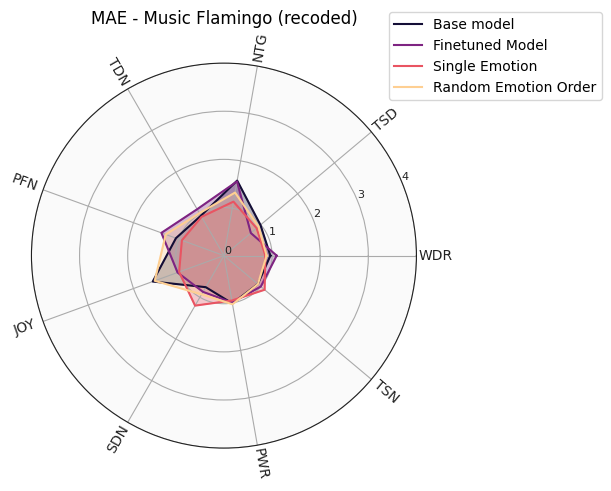

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Music Flamingo (recoded)'}>)

In [80]:
mf_metrics = [mf_base_metrics[0]['mae'], mf_finetuned_metrics[0]['mae'], mf_single_emo_metrics[0]['mae'], mf_random_metrics[0]['mae']]
mf_legends = ['Base model', 'Finetuned Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(mf_metrics, mf_legends, title = 'MAE - Music Flamingo (recoded)', max_tick=4)

[0.095, 0.245, 0.108, 0.476, 0.472, 0.314, 0.278, 0.454, 0.324, 0.095]
[0, 0, 0, 0.012, 0.011, 0.237, 0.005, 0.455, 0.24, 0]
[0.187, 0.169, 0.175, 0.467, 0.523, 0.449, 0.161, 0.407, 0.183, 0.187]
[0.271, 0.119, 0.195, 0.285, 0.266, 0.322, 0.19, 0.486, 0.382, 0.271]


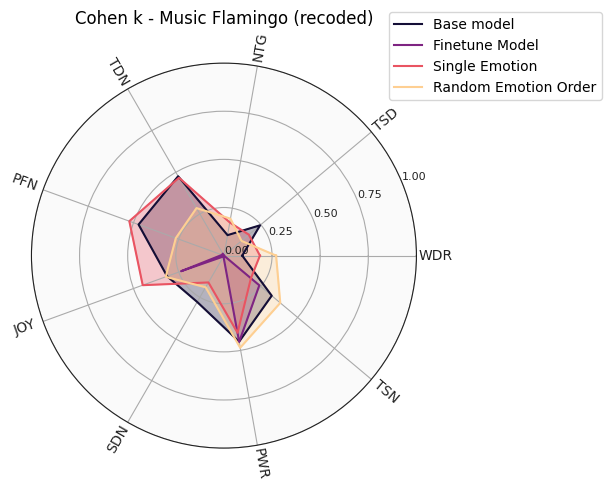

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Cohen k - Music Flamingo (recoded)'}>)

In [81]:
mf_metrics = [mf_base_metrics[0]['kappa'], mf_finetuned_metrics[0]['kappa'], mf_single_emo_metrics[0]['kappa'], mf_random_metrics[0]['kappa']]
mf_legends = ['Base model', 'Finetune Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(mf_metrics, mf_legends, title = 'Cohen k - Music Flamingo (recoded)', max_tick=1)

[48.881, 51.192, 30.611, 32.485, 26.989, 21.146, 18.206, 26.911, 21.05, 48.881]


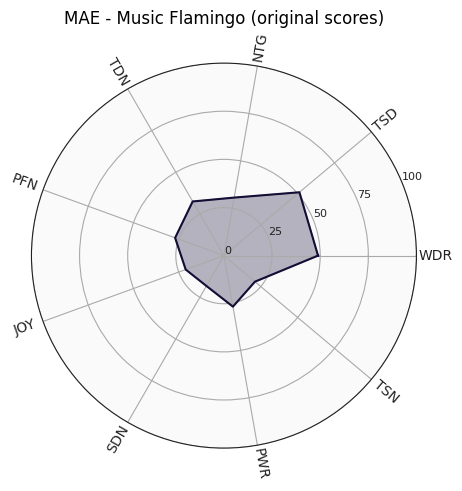

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Music Flamingo (original scores)'}>)

In [82]:
emo_radar_charts([mf_og_metrics[0]['mae']], title = 'MAE - Music Flamingo (original scores)', max_tick=100)

[0.241, 0.248, 0.396, 0.239, 0.265, 0.393, 0.189, 0.252, 0.23, 0.241]
[0.489, 0.512, 0.306, 0.325, 0.27, 0.211, 0.182, 0.269, 0.21, 0.489]


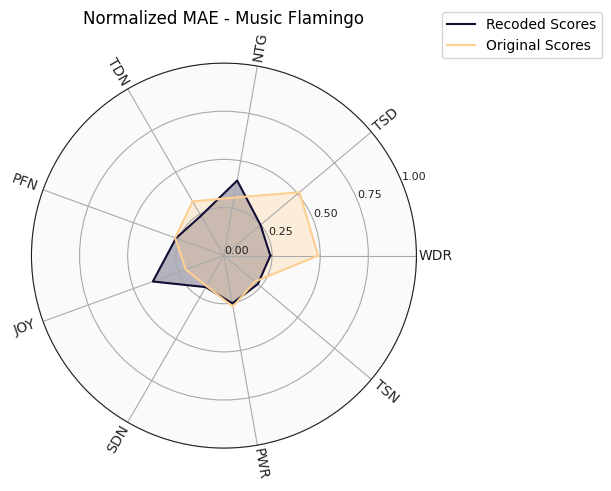

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Normalized MAE - Music Flamingo'}>)

In [83]:
mf_metrics = [mf_base_metrics[0]['nmae'], mf_og_metrics[0]['nmae']]
mf_legends = ['Recoded Scores', 'Original Scores']
emo_radar_charts(mf_metrics, mf_legends, title = 'Normalized MAE - Music Flamingo', max_tick=1)

#### Voxtral Charts

[1.026, 0.922, 1.191, 1.139, 1.148, 2.165, 1.252, 1.722, 1.062, 1.026]
[1.035, 0.757, 0.991, 1.017, 0.878, 0.791, 0.652, 1.0, 0.852, 1.035]
[1.217, 1.504, 1.209, 1.661, 1.174, 1.287, 2.078, 1.298, 1.8, 1.217]
[0.868, 0.904, 1.33, 1.261, 1.391, 1.496, 1.096, 1.212, 1.061, 0.868]


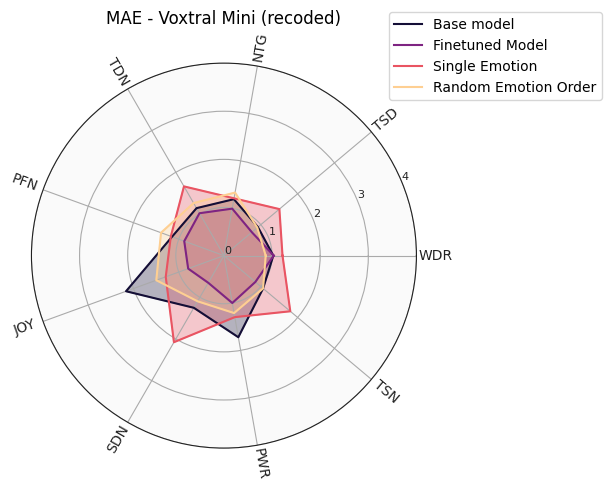

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Voxtral Mini (recoded)'}>)

In [84]:
voxtral_metrics = [voxtral_base_metrics[0]['mae'], voxtral_finetuned_metrics[0]['mae'], voxtral_single_emo_metrics[0]['mae'], voxtral_random_metrics[0]['mae']]
voxtral_legends = ['Base model', 'Finetuned Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(voxtral_metrics, voxtral_legends, title = 'MAE - Voxtral Mini (recoded)', max_tick=4)

[0.16, 0.203, 0.143, 0.234, 0.303, 0.097, 0.223, 0.114, 0.273, 0.16]
[0.24, 0.319, 0.528, 0.562, 0.595, 0.607, 0.588, 0.577, 0.519, 0.24]
[0, 0.044, 0, 0.087, 0.189, 0, 0.031, 0.046, 0.021, 0]
[0.215, 0.24, 0.062, 0.157, 0.101, 0.156, 0.202, 0.136, 0.139, 0.215]


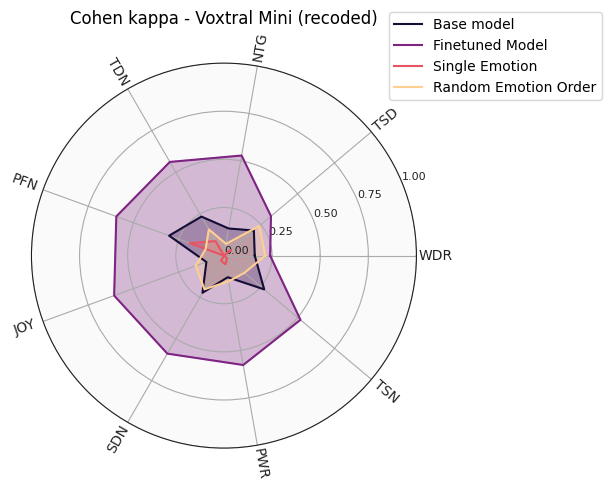

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Cohen kappa - Voxtral Mini (recoded)'}>)

In [85]:
voxtral_metrics = [voxtral_base_metrics[0]['kappa'], voxtral_finetuned_metrics[0]['kappa'], voxtral_single_emo_metrics[0]['kappa'], voxtral_random_metrics[0]['kappa']]
voxtral_legends = ['Base model', 'Finetuned Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(voxtral_metrics, voxtral_legends, title = 'Cohen kappa - Voxtral Mini (recoded)', max_tick=1)

[58.186, 49.087, 30.13, 32.375, 28.549, 15.451, 24.622, 19.645, 18.59, 58.186]


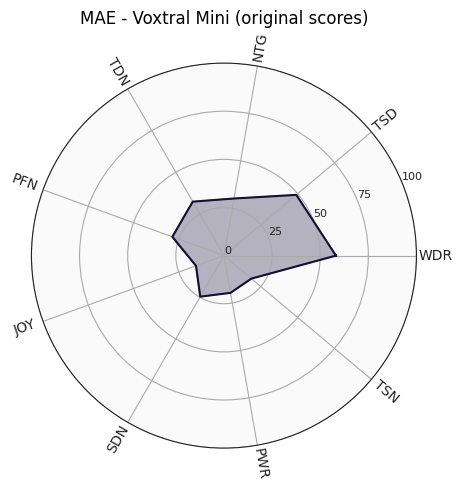

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Voxtral Mini (original scores)'}>)

In [86]:
emo_radar_charts([voxtral_og_metrics[0]['mae']], title = 'MAE - Voxtral Mini (original scores)', max_tick=100)

[0.257, 0.23, 0.298, 0.285, 0.287, 0.541, 0.313, 0.43, 0.265, 0.257]
[0.582, 0.491, 0.301, 0.324, 0.285, 0.155, 0.246, 0.196, 0.186, 0.582]


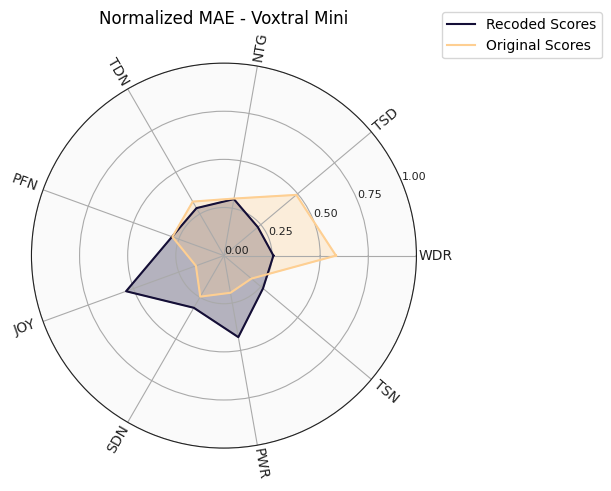

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Normalized MAE - Voxtral Mini'}>)

In [87]:
mf_metrics = [voxtral_base_metrics[0]['nmae'], voxtral_og_metrics[0]['nmae']]
mf_legends = ['Recoded Scores', 'Original Scores']
emo_radar_charts(mf_metrics, mf_legends, title = 'Normalized MAE - Voxtral Mini', max_tick=1)

#### Music Flamingo v. Voxtral Charts

[0.965, 0.991, 1.583, 0.957, 1.061, 1.574, 0.757, 1.009, 0.92, 0.965]
[1.096, 0.73, 1.565, 1.113, 1.383, 1.026, 0.87, 0.991, 1.0, 1.096]
[1.026, 0.922, 1.191, 1.139, 1.148, 2.165, 1.252, 1.722, 1.062, 1.026]
[1.035, 0.757, 0.991, 1.017, 0.878, 0.791, 0.652, 1.0, 0.852, 1.035]


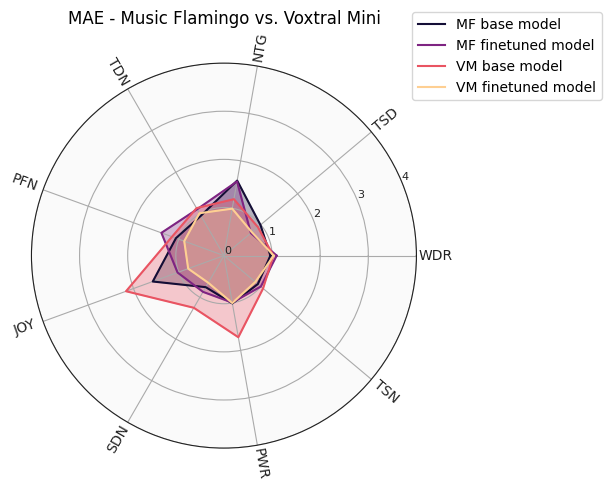

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Music Flamingo vs. Voxtral Mini'}>)

In [88]:
metrics = [mf_base_metrics[0]['mae'],  mf_finetuned_metrics[0]['mae'], voxtral_base_metrics[0]['mae'],voxtral_finetuned_metrics[0]['mae']]
legends = ['MF base model', 'MF finetuned model','VM base model',  'VM finetuned model']
emo_radar_charts(metrics, legends, title='MAE - Music Flamingo vs. Voxtral Mini')

[0.095, 0.245, 0.108, 0.476, 0.472, 0.314, 0.278, 0.454, 0.324, 0.095]
[0, 0, 0, 0.012, 0.011, 0.237, 0.005, 0.455, 0.24, 0]
[0.16, 0.203, 0.143, 0.234, 0.303, 0.097, 0.223, 0.114, 0.273, 0.16]
[0.24, 0.319, 0.528, 0.562, 0.595, 0.607, 0.588, 0.577, 0.519, 0.24]


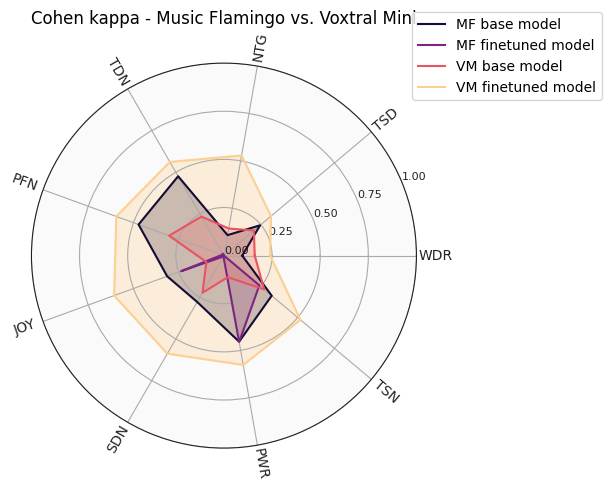

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Cohen kappa - Music Flamingo vs. Voxtral Mini'}>)

In [89]:
metrics = [mf_base_metrics[0]['kappa'],  mf_finetuned_metrics[0]['kappa'], voxtral_base_metrics[0]['kappa'],voxtral_finetuned_metrics[0]['kappa']]
legends = ['MF base model', 'MF finetuned model','VM base model',  'VM finetuned model']
emo_radar_charts(metrics, legends, title='Cohen kappa - Music Flamingo vs. Voxtral Mini', max_tick=1)

[0.241, 0.248, 0.396, 0.239, 0.265, 0.393, 0.189, 0.252, 0.23, 0.241]
[0.274, 0.183, 0.391, 0.278, 0.346, 0.257, 0.217, 0.248, 0.25, 0.274]
[0.489, 0.512, 0.306, 0.325, 0.27, 0.211, 0.182, 0.269, 0.21, 0.489]
[0.257, 0.23, 0.298, 0.285, 0.287, 0.541, 0.313, 0.43, 0.265, 0.257]
[0.259, 0.189, 0.248, 0.254, 0.22, 0.198, 0.163, 0.25, 0.213, 0.259]
[0.582, 0.491, 0.301, 0.324, 0.285, 0.155, 0.246, 0.196, 0.186, 0.582]


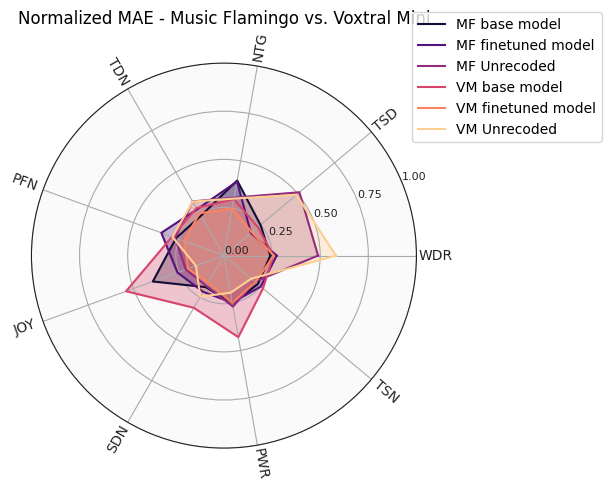

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Normalized MAE - Music Flamingo vs. Voxtral Mini'}>)

In [90]:
metrics = [mf_base_metrics[0]['nmae'],  mf_finetuned_metrics[0]['nmae'], mf_og_metrics[0]['nmae'],voxtral_base_metrics[0]['nmae'],voxtral_finetuned_metrics[0]['nmae'], voxtral_og_metrics[0]['nmae']]
legends = ['MF base model', 'MF finetuned model', 'MF Unrecoded','VM base model', 'VM finetuned model', 'VM Unrecoded']
emo_radar_charts(metrics, legends, title='Normalized MAE - Music Flamingo vs. Voxtral Mini', max_tick=1)

### Bar Charts

In [91]:
def emo_bar_chart(error,errors_list, legends_list,title = 'Radar Chart', min_tick = 0, max_tick = 4):

    fig, ax = plt.subplots(figsize=(9, 6))

    # X positions for each emotion category
    x = np.arange(len(emotions_col))

    # Width of each bar (depends on number of groups)
    width = (1/len(errors_list))*.8
    mult = 0
    
    colors_magma = plt.cm.magma(np.linspace(.1, .9, len(errors_list)))

    # Loop through each set of errors
    for i,e_list in enumerate(errors_list) :

         # Shift bars for grouped display
        offset = width * mult

        # Plot bars for current error metric
        ax.bar(x + offset,
               e_list[0][error],
               width=width,
               color=colors_magma[i],
               label = legends_list[i])
        
        # Add horizontal line for global value
        ax.axhline(y=e_list[1][error],
            color=colors_magma[i],
            linewidth=1.5,
            linestyle='--',
            label= f'{'Global'} {error} ({e_list[1][error]:.3})')

        mult += 1
            
    ax.set_ylabel(error)
    ax.set_title(title)

    plt.xticks(ticks=x, labels=emotions_col, rotation=45, ha='right')

    # Rearange labels (global labels in second position)
    handles, labels = ax.get_legend_handles_labels()
    mid = int(len(handles)/2)
    handles = handles[mid:] + handles[:mid]
    labels = labels[mid:] + labels[:mid]
    ax.legend(handles=handles,labels=labels)
    ax.set_ylim(min_tick, max_tick)
    ax.grid(which='both',axis='y', linestyle='-', alpha=.5)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

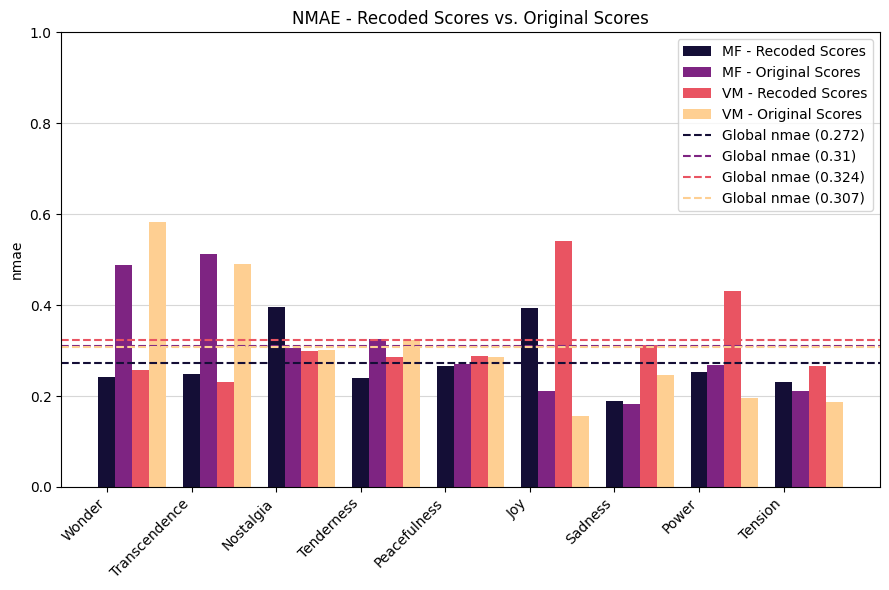

In [92]:
metrics = [mf_base_metrics,  mf_og_metrics, voxtral_base_metrics, voxtral_og_metrics]
legends = ['MF - Recoded Scores', 'MF - Original Scores','VM - Recoded Scores',  'VM - Original Scores']
emo_bar_chart('nmae', metrics, legends, title='NMAE - Recoded Scores vs. Original Scores', max_tick=1)

In [93]:
import math
for m in metrics:
    s = np.var(m[0]['nmae'])
    mu = np.mean(m[0]['nmae'])
    print(round(math.sqrt(s), 3), round(mu,3))
    

0.068 0.273
0.112 0.308
0.094 0.323
0.135 0.307


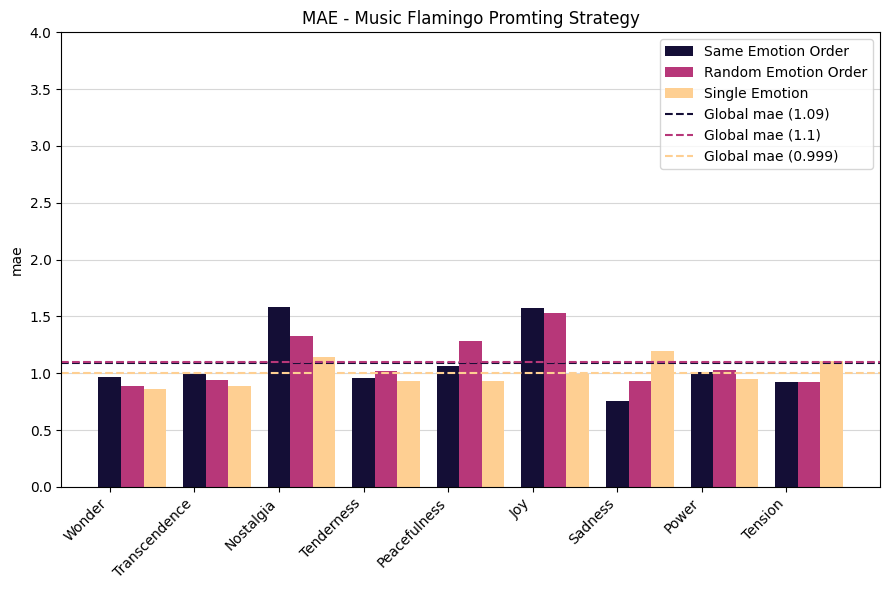

In [94]:
mf_metrics = [mf_base_metrics, mf_random_metrics, mf_single_emo_metrics]
mf_legends = ['Same Emotion Order', 'Random Emotion Order', 'Single Emotion']
emo_bar_chart('mae',mf_metrics, mf_legends, title = 'MAE - Music Flamingo Promting Strategy', max_tick=4)

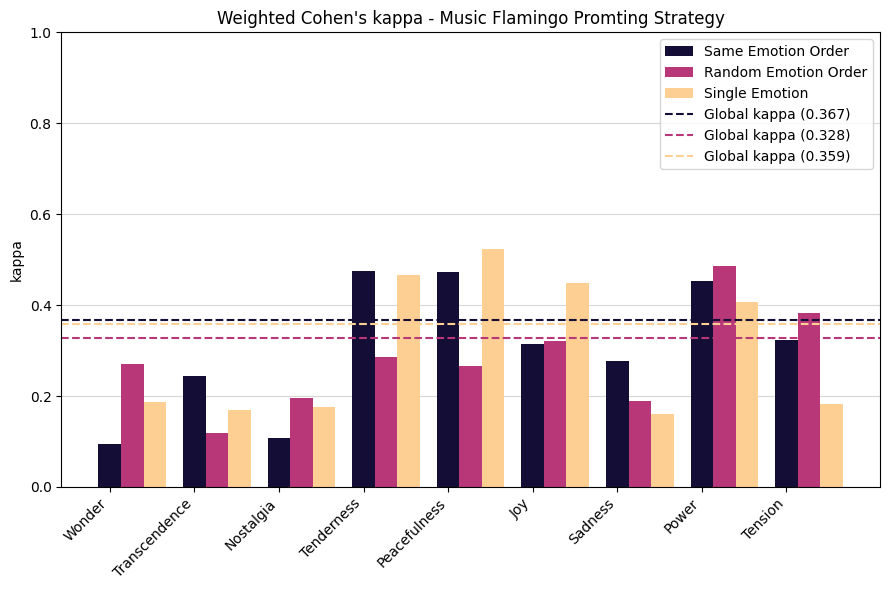

In [95]:
mf_metrics = [mf_base_metrics, mf_random_metrics, mf_single_emo_metrics]
mf_legends = ['Same Emotion Order', 'Random Emotion Order', 'Single Emotion']
emo_bar_chart('kappa',mf_metrics, mf_legends, title = 'Weighted Cohen\'s kappa - Music Flamingo Promting Strategy', max_tick=1)

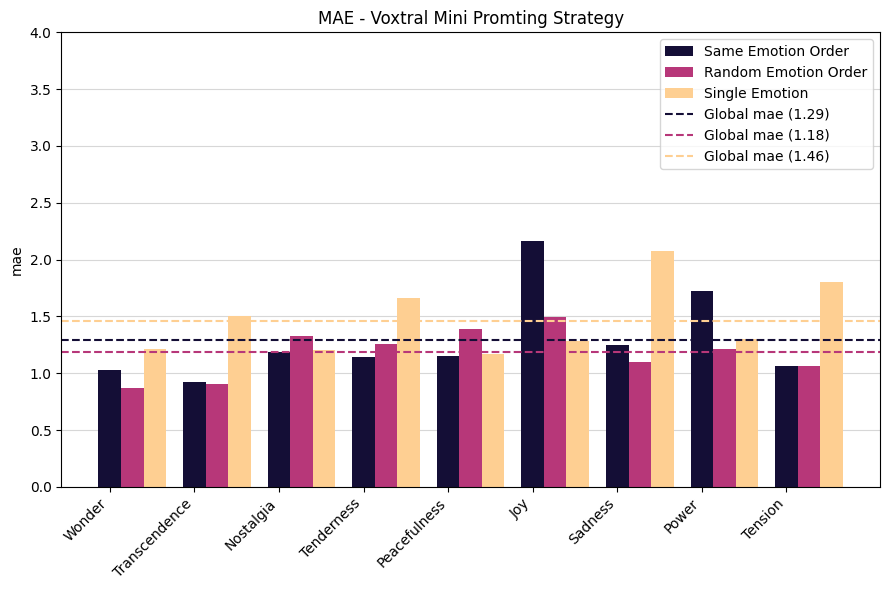

In [96]:
mf_metrics = [voxtral_base_metrics, voxtral_random_metrics, voxtral_single_emo_metrics]
mf_legends = ['Same Emotion Order', 'Random Emotion Order', 'Single Emotion']
emo_bar_chart('mae',mf_metrics, mf_legends, title = 'MAE - Voxtral Mini Promting Strategy', max_tick=4)

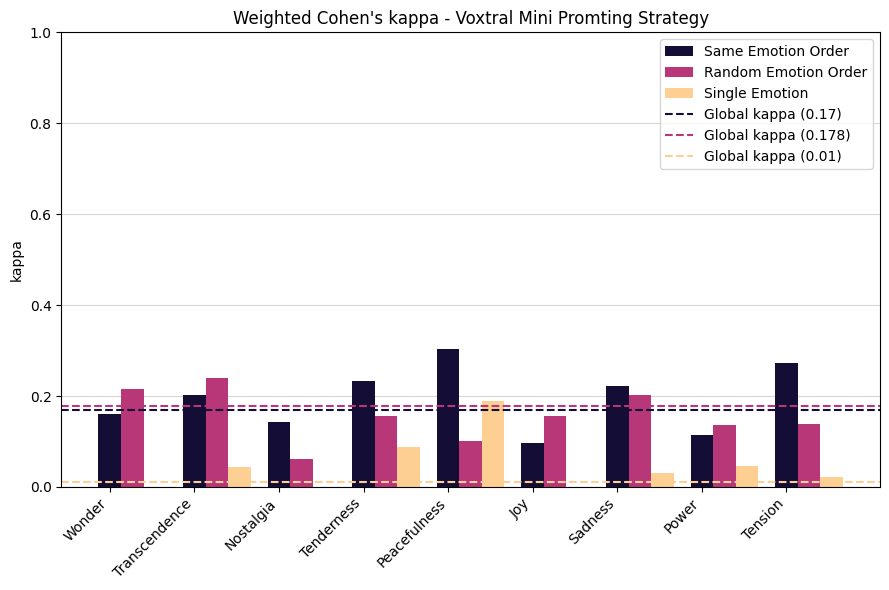

In [97]:
mf_metrics = [voxtral_base_metrics, voxtral_random_metrics, voxtral_single_emo_metrics]
mf_legends = ['Same Emotion Order', 'Random Emotion Order', 'Single Emotion']
emo_bar_chart('kappa',mf_metrics, mf_legends, title = 'Weighted Cohen\'s kappa - Voxtral Mini Promting Strategy', max_tick=1)

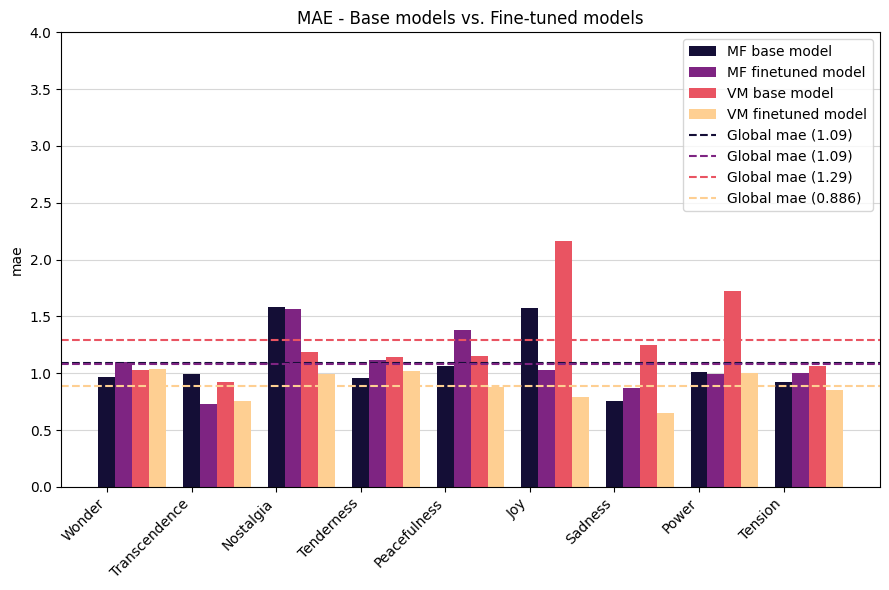

In [98]:
metrics = [mf_base_metrics,  mf_finetuned_metrics, voxtral_base_metrics,voxtral_finetuned_metrics]
legends = ['MF base model', 'MF finetuned model','VM base model',  'VM finetuned model']
emo_bar_chart('mae', metrics, legends, title='MAE - Base models vs. Fine-tuned models', max_tick=4)

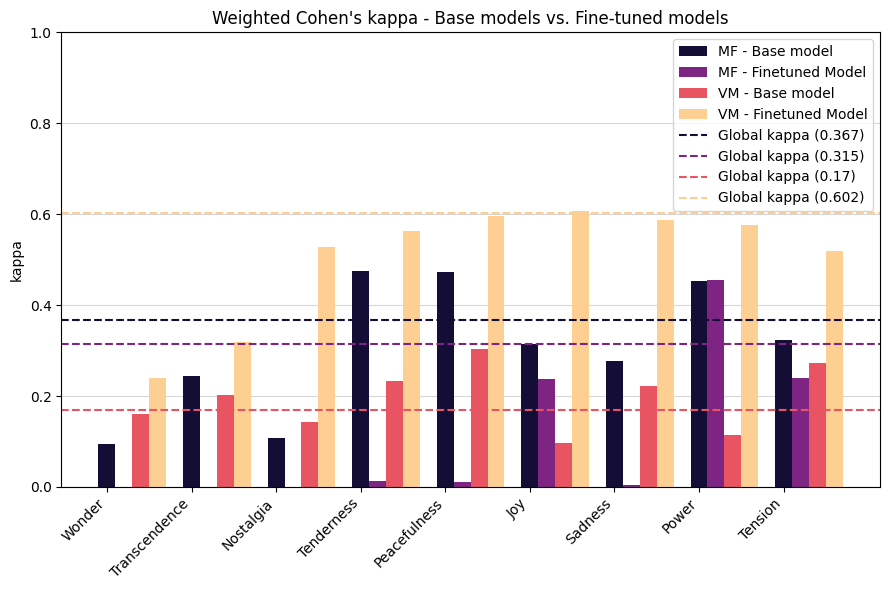

In [99]:
metrics = [mf_base_metrics, mf_finetuned_metrics, voxtral_base_metrics, voxtral_finetuned_metrics]
legends = ['MF - Base model', 'MF - Finetuned Model', 'VM - Base model', 'VM - Finetuned Model']
emo_bar_chart('kappa',metrics, legends, title = 'Weighted Cohen\'s kappa - Base models vs. Fine-tuned models', max_tick=1)

# Confusion Matrix

In [100]:
def  conf_matrix_plot (model_pred, test_data = test_recoded_df, ylabel='True Scores', normalization = None):

    fig, axs = plt.subplots(3, 3, figsize=(15, 15))
    axs = axs.flatten()

    for i, emo in enumerate(emotions_col):

        # Mask the missing values
        mask = model_pred[emo].notna()
        actual = test_data.loc[mask, emo]
        predicted = model_pred.loc[mask, emo]

        scores = [1,2,3,4,5]

        # Custom portion of the magma colormap
        colors_magma = colors.LinearSegmentedColormap.from_list(
            'truncated_magma_r',
            plt.get_cmap('magma_r')(np.linspace(0.1,0.9,50))
            )

        # Compute confusion matrix
        cm = confusion_matrix(actual,predicted,labels=scores, normalize=normalization)

        # Display the matrix 
        axs[i].matshow(cm, interpolation='nearest', cmap=colors_magma)
        axs[i].set(xticks=np.arange(cm.shape[1]),
                   yticks=np.arange(cm.shape[0]),
                   xticklabels=scores, 
                   yticklabels=scores,
                   title=emo,
                   ylabel=ylabel,
                   xlabel='Predicted Scores')
        
        # Add the values inside each cell with readable text color
        thresh = cm.max() / 2
        for row in range(cm.shape[0]):
            for col in range(cm.shape[1]):
                axs[i].text(col, row, f"{round(cm[row, col],2) if normalization != None else cm[row, col]}",
                            ha='center', va='center',
                            color='white' if cm[row, col] > thresh else 'black',
                            fontsize=12)
    
    fig.tight_layout()
    fig.show()


C:\Users\paulz\AppData\Local\Temp\ipykernel_27744\2584052850.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


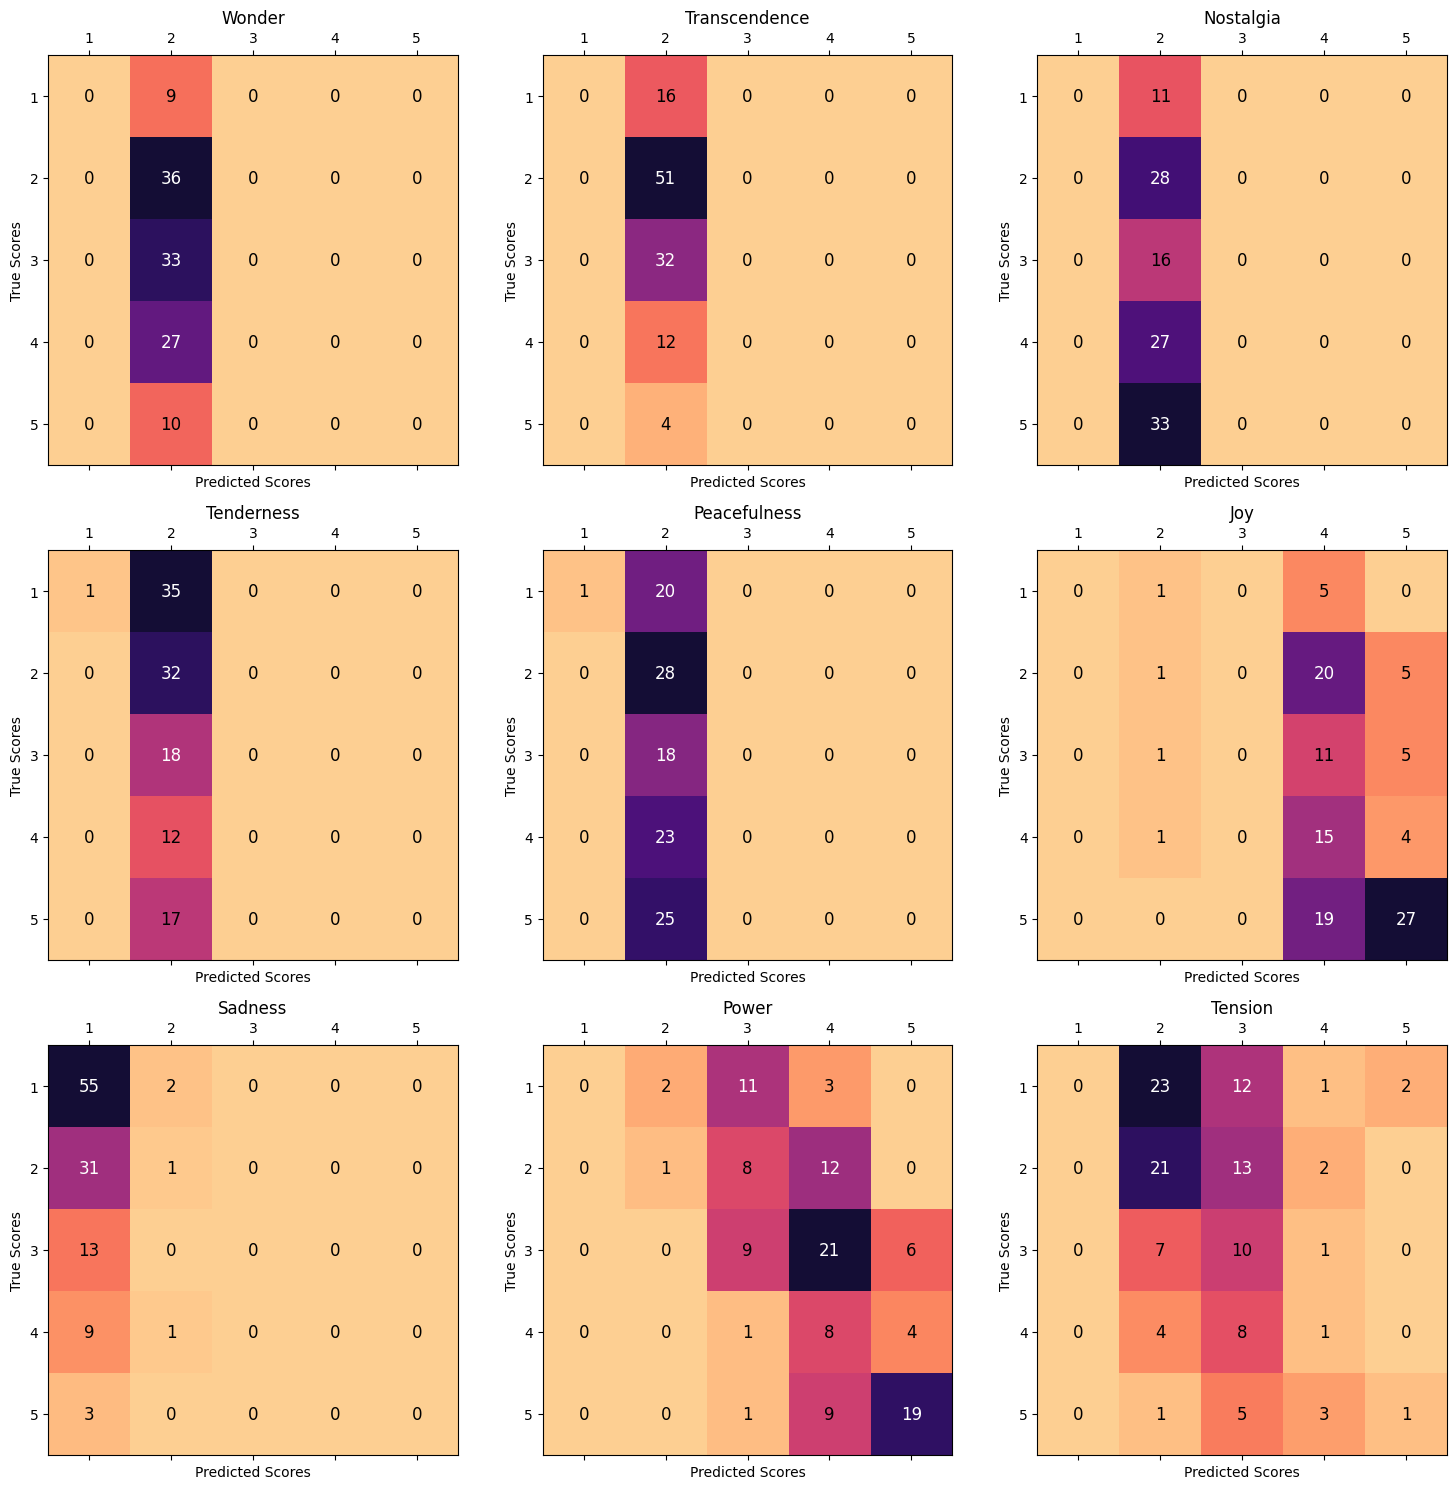

In [101]:
conf_matrix_plot(MF_finetuned_df, normalization=None)

### Loss chart

In [102]:
mf_train_loss = [0.2926,0.0412,0.0404,0.0397,0.0391,0.0385,0.0375]
mf_val_loss = [0.0422,0.0404,0.0401,0.0396,0.0401,0.0401,0.0406]
vm_train_loss = [0.2002, 0.1767, 0.1654, 0.1571, 0.1474, 0.1365, 0.1243]
vm_val_loss = [0.1865 ,0.1718 ,0.1778 ,0.1701 ,0.1789 ,0.1885 ,0.1868]

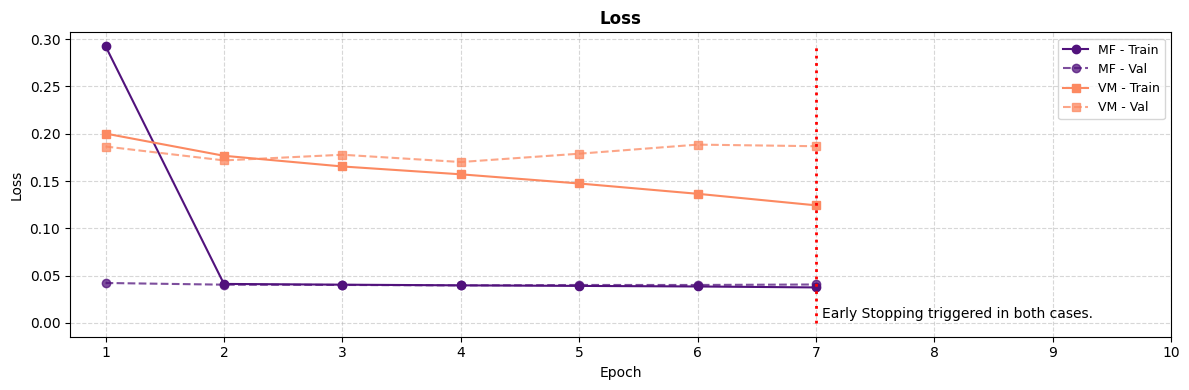

In [103]:
# Loss plot
fig, ax = plt.subplots(figsize=(12, 4))

# MF train/valid loss
ax.plot(range(1,len(mf_train_loss)+1),  mf_train_loss,  marker="o", lw=1.5, label="MF - Train",  color=plt.cm.magma(.25))
ax.plot(range(1,len(mf_val_loss)+1),  mf_val_loss, marker="o", lw=1.5, ls="--", label="MF - Val", color=plt.cm.magma(.25), alpha=0.75)
# VM train/valid loss
ax.plot(range(1,len(vm_train_loss)+1), vm_train_loss, marker="s", lw=1.5, label="VM - Train", color=plt.cm.magma(.75))
ax.plot(range(1,len(vm_val_loss)+1), vm_val_loss,marker="s", lw=1.5, ls="--", label="VM - Val", color=plt.cm.magma(.75), alpha=0.75)
# Early stopping
plt.vlines(x=7, ymin=0, ymax=max(mf_train_loss), colors='red', ls=':', lw=2)

ax.annotate('Early Stopping triggered in both cases.', xy=(7, 0.05), xytext=(7.05, 0.005))

ax.set_title("Loss", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_xticks(np.linspace(1,10,10))
ax.legend(fontsize=9); ax.grid(True, ls="--", alpha=0.5)

fig.tight_layout()
plt.show()

# MJF Data Analysis

In [104]:
import pingouin as pg
import decimal

In [105]:
# Load annotations and VM predictions
mjf_df = pd.read_csv('../results/mjf_tracks_annoted.csv',
                     delimiter=';',
                     encoding='cp1252',
                     na_values='NA')

mjf_rater_01_df = pd.read_csv('../results/raters/rater_01.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

mjf_rater_02_df = pd.read_csv('../results/raters/rater_02.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

mjf_rater_03_df = pd.read_csv('../results/raters/rater_03.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

mjf_rater_04_df = pd.read_csv('../results/raters/rater_04.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

mjf_rater_05_df = pd.read_csv('../results/raters/rater_05.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

mjf_rater_06_df = pd.read_csv('../results/raters/rater_06.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

mjf_rater_07_df = pd.read_csv('../results/raters/rater_07.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

mjf_rater_08_df = pd.read_csv('../results/raters/rater_08.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

mjf_rater_09_df = pd.read_csv('../results/raters/rater_09.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

mjf_rater_10_df = pd.read_csv('../results/raters/rater_10.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')


mjf_vm_df = pd.read_csv('../results/voxtral_mjf_results.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

Genre
Jazz       19
Rock       10
Pop        10
Soul        6
Hip Hop     6
Blues       4
Other       5
Name: count, dtype: int64


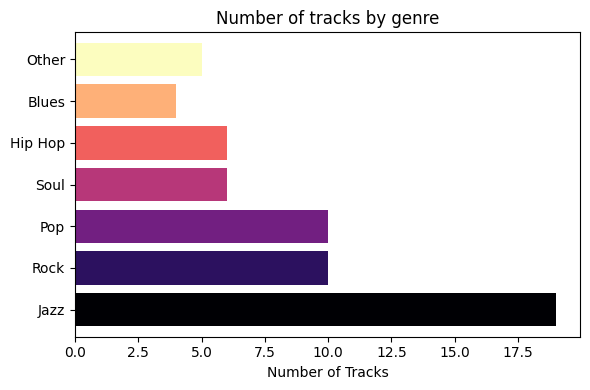

In [106]:
# Count genre occurences
counts = mjf_df["Genre"].value_counts().sort_values(ascending=False)

# Concat genre with less than 4 occurences
mask = counts < 4
other = counts[mask].sum()
counts = counts[~mask]
counts['Other'] = other 
print(counts)

# Pot genre
colors_magma = plt.cm.magma(np.linspace(0, 1, len(counts)))

plt.figure(figsize=(6, 4))
counts.plot(kind="barh", 
            width=0.8,
            color=colors_magma)
plt.title("Number of tracks by genre")
plt.xlabel("Number of Tracks") 
plt.ylabel("")
plt.tight_layout()
plt.show()

In [107]:
mjf_raters = [mjf_rater_01_df, mjf_rater_02_df, mjf_rater_03_df, mjf_rater_04_df, mjf_rater_05_df,
              mjf_rater_06_df, mjf_rater_07_df,  mjf_rater_08_df, mjf_rater_09_df, mjf_rater_10_df]
mjf_mean_df = pd.concat(mjf_raters).reset_index().groupby('index').mean()

In [108]:
emotions = emotions_col
participants = {"P1": mjf_rater_01_df, "P2": mjf_rater_02_df, "P3": mjf_rater_03_df,
                "P4": mjf_rater_04_df, "P5": mjf_rater_05_df, "P6": mjf_rater_06_df,
                "P7": mjf_rater_07_df, "P8": mjf_rater_08_df, "P9": mjf_rater_09_df, "P10": mjf_rater_10_df}

results = []
for emotion in emotions:
    frames = []
    for name, df_p in participants.items():
        tmp = df_p[["N° Extrait", emotion]].copy()
        tmp["rater"] = name
        tmp = tmp.rename(columns={emotion: "rating", "N° Extrait": "target"})
        frames.append(tmp)

    df_long = pd.concat(frames, ignore_index=True)

    icc = pg.intraclass_corr(
        data=df_long,
        targets="target",
        raters="rater",
        ratings="rating"
    ).set_index("Type")

    # Extraire ICC(3,1) — two-way mixed, single measures
    row = icc.loc["ICC(A,k)"]
    results.append({
        "Emotion": emotion,
        "ICC": round(row["ICC"], 3),
        "CI95%": row["CI95"],
        "pval": round(row["pval"], 4)
    })

df_results = pd.DataFrame(results)
df_results

,Emotion,ICC,CI95%,pval
0,Wonder,0.678,"[0.55, 0.79]",0.0
1,Transcendence,0.533,"[0.35, 0.68]",0.0
2,Nostalgia,0.753,"[0.65, 0.84]",0.0
3,Tenderness,0.885,"[0.83, 0.93]",0.0
4,Peacefulness,0.896,"[0.85, 0.93]",0.0
5,Joy,0.851,"[0.79, 0.9]",0.0
6,Sadness,0.927,"[0.9, 0.95]",0.0
7,Power,0.905,"[0.86, 0.94]",0.0
8,Tension,0.774,"[0.68, 0.85]",0.0


In [109]:
df_long.to_csv('all_ratings.csv')

In [110]:
frames = []
for name, df_p in participants.items():
    melted = df_p.melt(
        id_vars="N° Extrait",
        value_vars=emotions,
        var_name="emotion",
        value_name="rating"
    )
    # Créer une clé unique extrait+émotion
    melted["target"] = melted["N° Extrait"].astype(str) + "_" + melted["emotion"]
    melted["rater"] = name
    frames.append(melted[["target", "rater", "rating"]])

df_long = pd.concat(frames, ignore_index=True)

icc_global = pg.intraclass_corr(
    data=df_long,
    targets="target",
    raters="rater",
    ratings="rating"
).set_index("Type")

print(icc_global[["ICC", "CI95", "pval"]])

               ICC          CI95  pval
Type                                  
ICC(1,1)  0.385984  [0.35, 0.42]   0.0
ICC(A,1)  0.387984  [0.35, 0.43]   0.0
ICC(C,1)  0.401048  [0.37, 0.44]   0.0
ICC(1,k)  0.862755  [0.84, 0.88]   0.0
ICC(A,k)  0.863750  [0.84, 0.88]   0.0
ICC(C,k)  0.870059  [0.85, 0.89]   0.0


In [111]:
mjf_mean_df[emotions_col].head()

,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Sadness,Power,Tension
index,,,,,,,,,
0,2.1,1.9,2.5,1.2,1.5,4.1,1.3,3.4,2.1
1,3.3,2.6,2.4,2.8,3.0,2.8,1.9,2.1,3.0
2,3.5,4.0,2.7,2.3,2.2,3.4,2.0,4.4,2.4
3,2.7,2.6,3.7,2.0,2.1,3.8,1.9,3.4,2.6
4,2.9,3.2,3.0,4.0,4.8,2.6,2.2,1.6,2.1


In [112]:
def round_half_up(x):
    return int(decimal.Decimal(str(x)).quantize(decimal.Decimal(1), rounding=decimal.ROUND_HALF_UP))

In [113]:
mjf_df[emotions_col] = mjf_mean_df[emotions_col].apply(lambda col: col.map(round_half_up))
mjf_df.head()

,Column1,Artist,Title,Year,Genre,Path,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness
0,0,Aloe Blacc,NaN,2018,Rock,0_Aloe Blacc--2018.mp3,2,2,3,1,2,4,3,2,1
1,1,Avishai Cohen's New York Division,NaN,2015,Jazz,1_Avishai Cohen's New York Division--2015.mp3,3,3,2,3,3,3,2,3,2
2,2,B.B. King,Jam Session (2ème),2011,Blues,2_B.B. King-Jam Session (2ème)-2011.mp3,4,4,3,2,2,3,4,2,2
3,3,B.B.King,The Thrill Is Gone,2000,Blues,3_B.B.King--2000.mp3,3,3,4,2,2,4,3,3,2
4,4,Bugge Wesseltoft and Friends,NaN,2015,Jazz,4_Bugge Wesseltoft and Friends--2015.mp3,3,3,3,4,5,3,2,2,2


C:\Users\paulz\AppData\Local\Temp\ipykernel_27744\1103995582.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


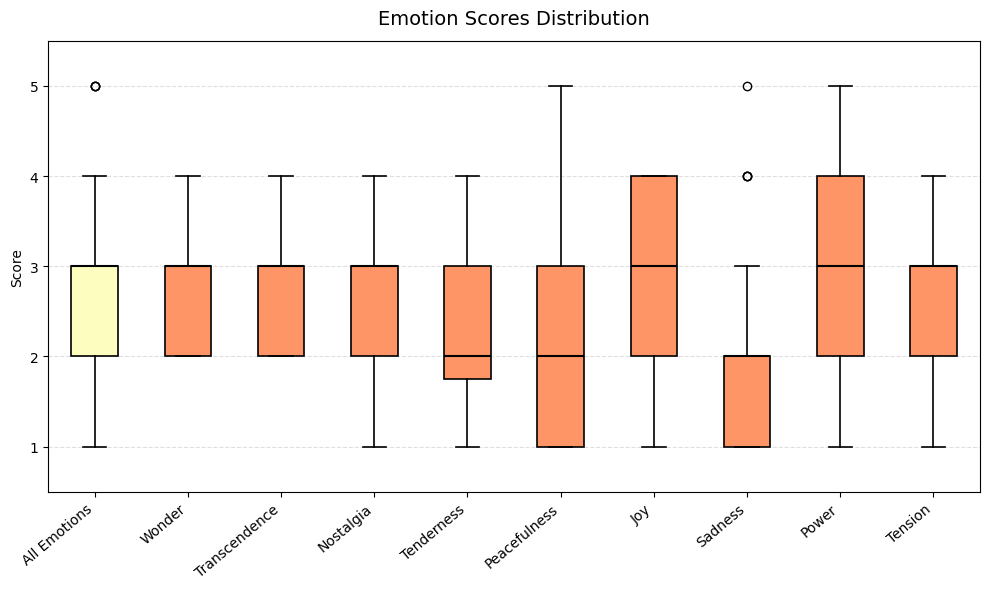

In [114]:
# Boxplot of the annotaions
scores = mjf_df[emotions_col].to_numpy().ravel()

emotion_data = [mjf_df[emo].dropna().values for emo in emotions_col]

data = [scores] + emotion_data
labels = ['All Emotions'] + emotions_col

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)

# Soft color palette (highlight "All")
colors_bar = ['#FCFDBFFF'] + ['#FD9567FF'] * len(emotions_col)
for patch, color in zip(box['boxes'], colors_bar):
    patch.set_facecolor(color)

# Styling
ax.set_title("Emotion Scores Distribution", fontsize=14, pad=12)
ax.set_ylabel("Score")
ax.set_ylim(0.5, 5.5)
ax.set_yticks(range(1, 6))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

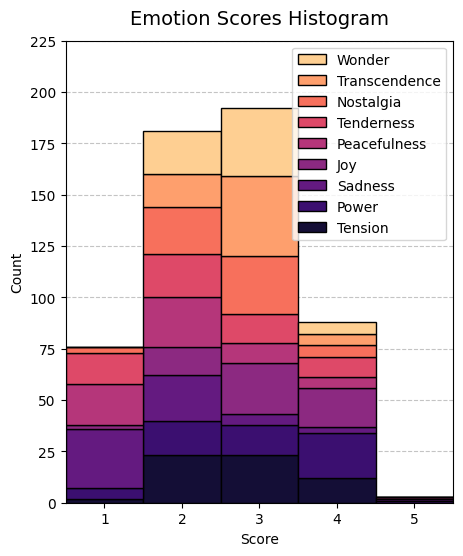

In [115]:
# Histogramm of the annotations
fig, ax = plt.subplots(figsize=(5, 6))

sns.histplot(mjf_df[emotions_col],
            stat='count',
            palette='magma_r',
            multiple = 'stack',
            fill=True,
            discrete=True,
            alpha = 1
            )

ax.set_title("Emotion Scores Histogram", fontsize=14, pad=12)
ax.set_xlabel("Score")
ax.set_xlim(0.5, 5.5)
ax.set_xticks(range(1, 6, 1))
ax.set_yticks(range(0, 250, 25))
ax.grid(which='both',axis='y', linestyle='--', alpha=.75)
ax.set_axisbelow(True)

plt.show

In [116]:
# errors between annotations and predictions
mjf_metrics = compute_metrics(model_pred=mjf_vm_df, test_data=mjf_df)
mjf_metrics

({'mae': [1.483, 0.717, 1.533, 1.533, 1.633, 1.767, 0.75, 1.583, 1.133],
  'nmae': [0.371, 0.179, 0.383, 0.383, 0.408, 0.442, 0.188, 0.396, 0.283],
  'nrmse': [0.417, 0.23, 0.452, 0.472, 0.504, 0.502, 0.29, 0.473, 0.359],
  'kappa': [-0.077, 0.093, -0.029, 0.083, 0.062, -0.083, 0.024, -0.053, 0.098],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 1.348, 'nmae': 0.337, 'nrmse': 0.421, 'kappa': 0.142})

C:\Users\paulz\AppData\Local\Temp\ipykernel_27744\2584052850.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


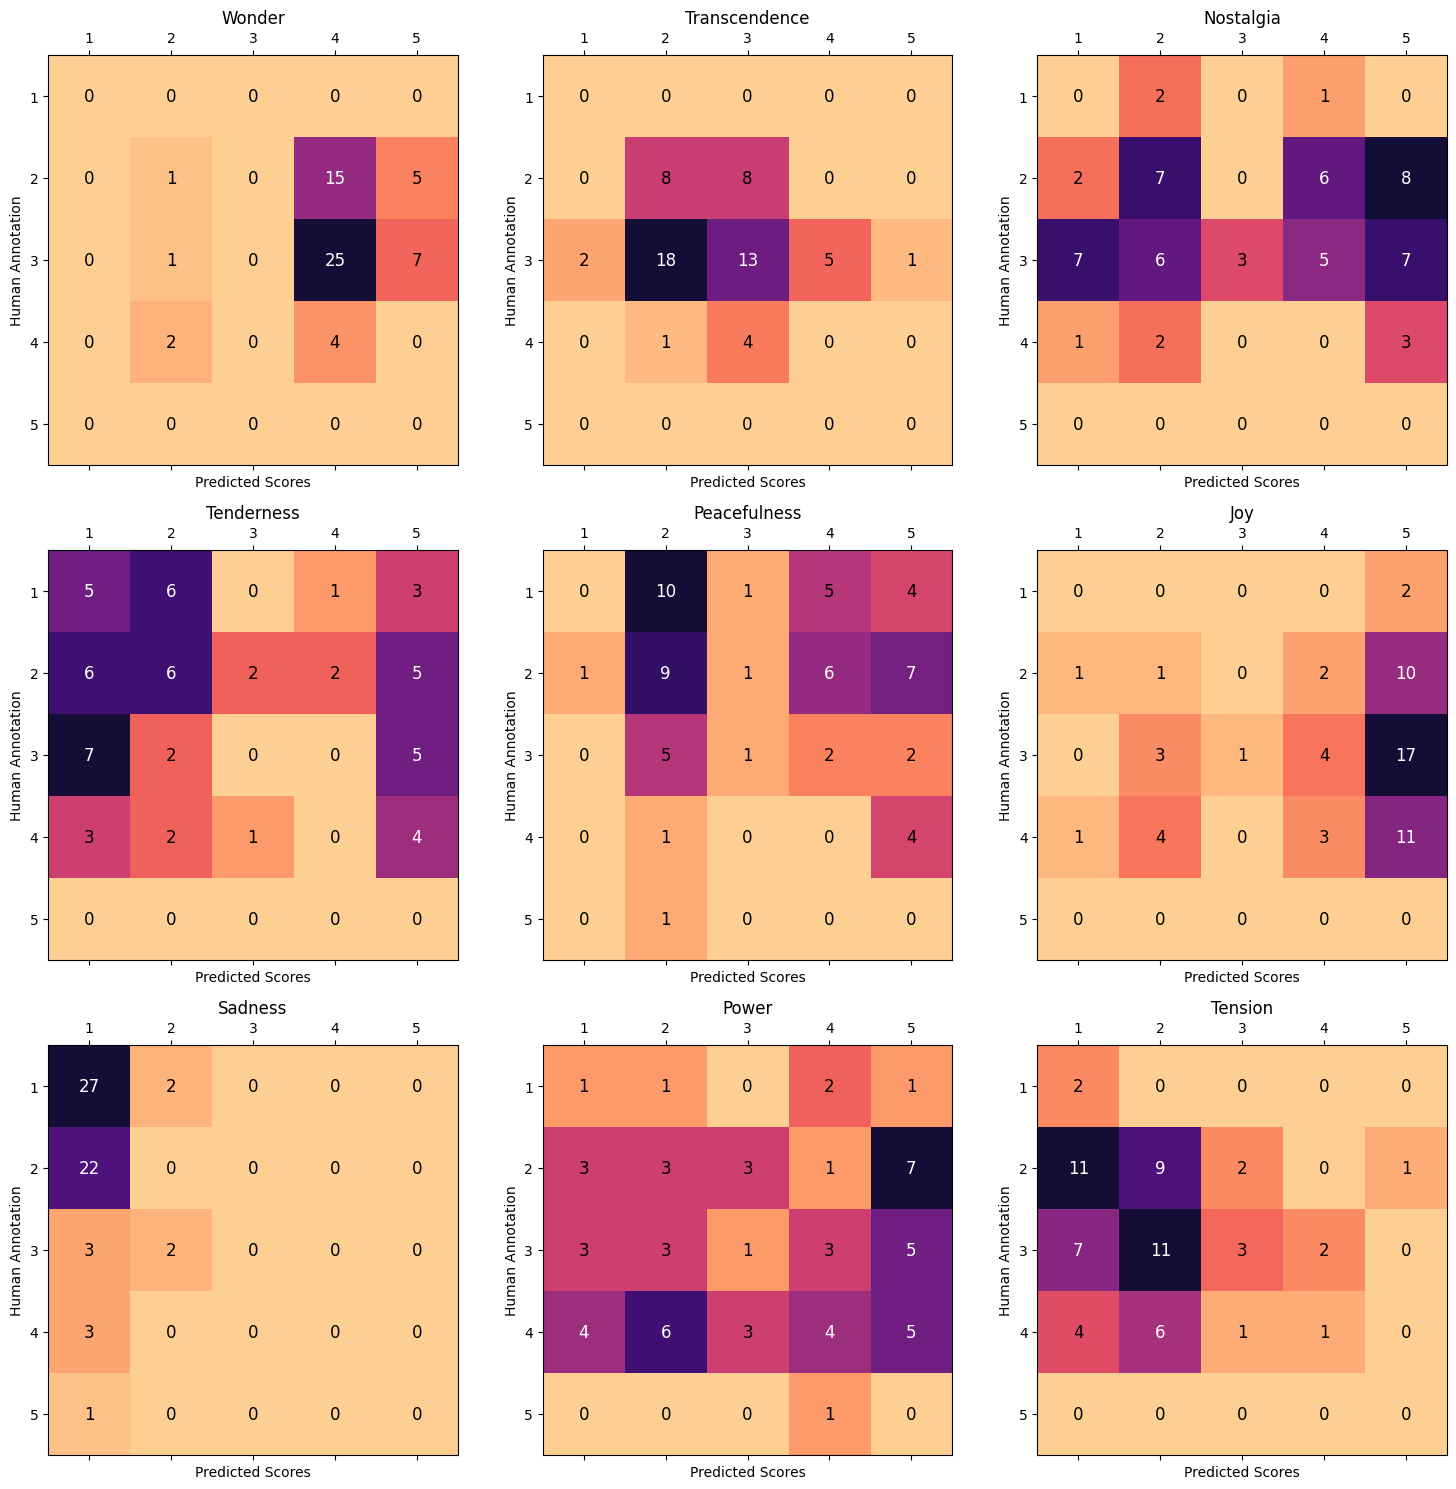

In [117]:
# Conf. matrix between annotations and predictions
conf_matrix_plot(mjf_vm_df, mjf_df, ylabel='Human Annotation')

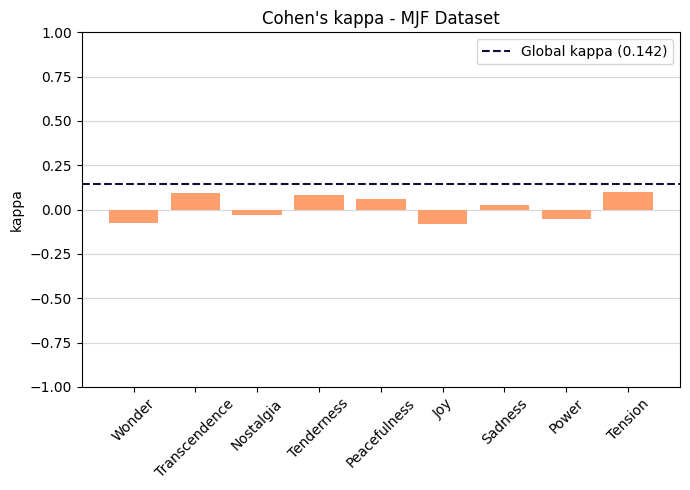

In [118]:
# Plot Cohen's kappa for each emotion
values =  mjf_metrics[0]['kappa']
labels = emotions_col

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(labels, 
        values, 
        color=plt.cm.magma(np.linspace(.8, 1, 1)))

ax.axhline(y = mjf_metrics[1]['kappa'],
           color=plt.cm.magma(np.linspace(0.1, 1, 1)),
           linestyle='--',
           label= f'{'Global'} kappa ({mjf_metrics[1]['kappa']:.3})')

plt.title('Cohen\'s kappa - MJF Dataset')
plt.ylabel('kappa')
plt.xticks(rotation=45)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=labels)
ax.set_ylim(-1, 1)
ax.grid(which='both',axis='y', linestyle='-', alpha=.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Track Analysis

In [120]:
BBKing_whole_track = {'Wonder': 4,'Transcendence': 3,'Nostalgia': 2,'Tenderness': 1,'Peacefulness': 2,'Joy': 5,'Sadness': 1,'Power': 5,'Tension': 2}
Idles_whole_track = {'Wonder': 4,'Transcendence': 3,'Nostalgia': 1,'Tenderness': 1,'Peacefulness': 1,'Joy': 5,'Sadness': 1,'Power': 5,'Tension': 5}
Simone_whole_track = {'Wonder': 5,'Transcendence': 4,'Nostalgia': 4,'Tenderness': 3,'Peacefulness': 4,'Joy': 5,'Sadness': 1,'Power': 5,'Tension': 1}
Raye_whole_track = {'Wonder': 4,'Transcendence': 3,'Nostalgia': 3,'Tenderness': 2,'Peacefulness': 2,'Joy': 5,'Sadness': 1,'Power': 5,'Tension': 2}
Wu_Tang_whole_track = {'Wonder': 5,'Transcendence': 3,'Nostalgia': 1,'Tenderness': 1,'Peacefulness': 2,'Joy': 5,'Sadness': 1,'Power': 5,'Tension': 4}
Yseult_whole_track = {'Wonder': 4,'Transcendence': 3,'Nostalgia': 4,'Tenderness': 2,'Peacefulness': 3,'Joy': 4,'Sadness': 1,'Power': 4,'Tension': 2}

C:\Users\paulz\AppData\Local\Temp\ipykernel_27744\1376836323.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


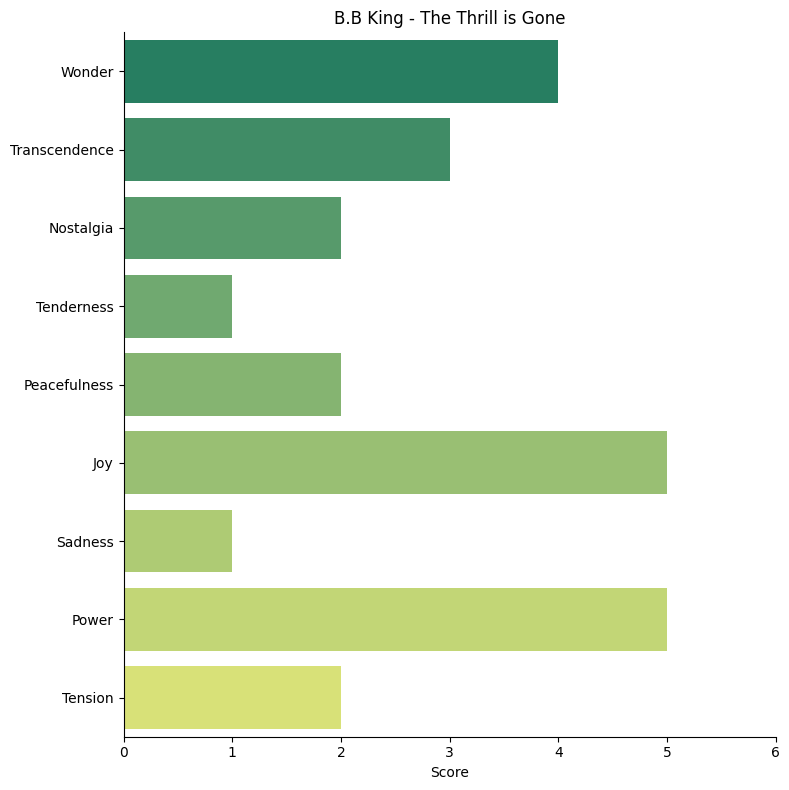

In [ ]:
def bar_plot(whole_track = dict, title = str()):

    fig, ax = plt.subplots(figsize=(8,8))

    sns.barplot(
        x = list(whole_track.values()),
        y = list(whole_track.keys()),
        orient='h',
        palette='summer'
    )
 
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('')
    ax.set_xlim(0, 6)
    # sns.despine()
 
    plt.tight_layout()
    plt.show()

bar_plot(BBKing_whole_track, 'B.B King - The Thrill is Gone')

In [121]:
def parse_emotion_data(text: str) -> tuple[str, dict[str, list], list[float]]:
    """
    Parse the raw text into:
      - track name (str)
      - emotions dict  { emotion_name: [score, ...] }
      - time_labels    [midpoint_seconds, ...]
    """

    BLOCK_HEADER = re.compile(r"\[(?P<track>.+?)\]\s*\[(?P<start>[\d.]+)s\s*[–\-]+\s*(?P<end>[\d.]+)s\]")
    EMOTION_LINE = re.compile(r"-\s*(?P<emotion>\w+):\s*(?P<score>[\d.]+)")
 
    track_name = ""
    windows: list[tuple[float, dict[str, float]]] = []
 
    current_start = None
    current_end = None
    current_emotions: dict[str, float] = {}
 
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
 
        header_match = BLOCK_HEADER.match(line)
        if header_match:
            # Save previous block if any
            if current_start is not None and current_emotions:
                mid = (current_start + current_end) / 2
                windows.append((mid, current_emotions))
 
            track_name = header_match.group("track").strip()
            current_start = float(header_match.group("start"))
            current_end = float(header_match.group("end"))
            current_emotions = {}
            continue
 
        emotion_match = EMOTION_LINE.match(line)
        if emotion_match and current_start is not None:
            current_emotions[emotion_match.group("emotion")] = float(
                emotion_match.group("score")
            )
 
    # Flush last block
    if current_start is not None and current_emotions:
        mid = (current_start + current_end) / 2
        windows.append((mid, current_emotions))
 
    if not windows:
        raise ValueError("No emotion data found in the input.")
 
    # Collect all emotion names (preserve insertion order from first block)
    all_emotions: list[str] = list(windows[0][1].keys())
    for _, emo_dict in windows[1:]:
        for e in emo_dict:
            if e not in all_emotions:
                all_emotions.append(e)
 
    time_labels = [w[0] for w in windows]
    emotions: dict[str, list[float]] = defaultdict(list)
    for _, emo_dict in windows:
        for e in all_emotions:
            emotions[e].append(emo_dict.get(e, float("nan")))
 
    return track_name, dict(emotions), time_labels

In [122]:
def plot_all_emotions(
    track_name: str,
    emotions: dict[str, list[float]],
    time_labels: list[float],
) -> None:

    colours = plt.cm.magma_r(np.linspace(0, 1, len(emotions)))
 
    fig, ax = plt.subplots(figsize=(13, 6))
    # fig.patch.set_facecolor("#0d0d0d")
    ax.set_facecolor("#f5f1f1")
 
    x = np.array(time_labels)
    x_ticks = x  # one tick per window mid-point
 
    for (emotion, scores), colour in zip(emotions.items(), colours):
        y = np.array(scores)
        ax.plot(
            x, y,
            color=colour,
            linewidth=1.5,
            linestyle = '-',
            marker="o",
            markersize=5,
            markerfacecolor=colour,
            markeredgewidth=0,
            label=emotion,
        )
 
    # Formatting
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{t:.0f}s" for t in x_ticks])
    ax.set_yticks(range(1, 7))
    ax.set_ylim(0.5, 5.5)
    ax.set_xlabel("Time")
    ax.set_ylabel("Score")
    ax.set_title(track_name, fontsize=14)
 
    ax.grid(axis="y", color="#222222", linewidth=0.5, linestyle="--", alpha = 0.5)
    ax.grid(axis="x", color="#1a1a1a", linewidth=0.5, linestyle="--", alpha = 0.5)
 
    legend = ax.legend(
        loc="best",
        framealpha=0.3,
        facecolor="#C0ADAD",
        edgecolor="#444444",
        # labelcolor="#dddddd",
        fontsize=9,
    )
 
    plt.tight_layout()
    plt.show()

In [123]:
def plot_emotions(
    track_name: str,
    emotions: dict[str, list[float]],
    time_labels: list[float],
) -> None:
    
    # colours = plt.cm.magma_r(np.linspace(0.5, 1, len(emotions)))
 
    x = np.array(time_labels)
    cols, rows = 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(14, 9), sharey=True)
    # fig.patch.set_facecolor("#0d0d0d")
    fig.suptitle(track_name)
 
    for idx, ax in enumerate(axes.flat):
        ax.set_facecolor("#f5f1f1")
        # for spine in ax.spines.values():
        #     spine.set_edgecolor("#2a2a2a")
 
        # if idx >= len(emotions):
        #     ax.set_visible(False)
        #     continue
 
        emotion = emotions_col[idx]
        scores = np.array(emotions[emotion])
        colour =  color=plt.cm.magma(np.linspace(.75, 1, 1))#colours[idx]
 
        ax.plot(x, scores, color=colour, linewidth=2, marker="o",
                markersize=4, markerfacecolor=colour, markeredgewidth=0)
        ax.fill_between(x, scores, 1, alpha=0.15, color=colour)
 
        ax.set_title(emotion, fontsize=10)
        ax.set_ylim(0.5, 5.5)
        ax.set_yticks(range(1, 6))
        ax.set_xticks(x)
        ax.set_xticklabels([f"{t:.0f}s" for t in x], rotation=45, ha="right", fontsize = 7)
        ax.tick_params(axis="y")
        ax.grid(axis="y", color="#222222", linewidth=0.5, linestyle="--", alpha = 0.5)
        ax.grid(axis="x", color="#1a1a1a", linewidth=0.5, linestyle="--", alpha = 0.5)
 
    plt.tight_layout()
    plt.show()

In [124]:
def heatmap_emotions(
    track_name: str,
    emotions: dict[str, list[float]],
    time_labels: list[float],
) -> None:

    # Build 2-D array: rows = emotions, cols = time windows
    matrix = np.array([emotions[e] for e in emotions_col], dtype=float)

    n_emotions, n_times = matrix.shape
    fig, ax = plt.subplots(figsize=(max(10, n_times * 1.1), max(4, n_emotions * 0.7)))

    im = ax.imshow(
        matrix,
        aspect="auto",
        cmap="summer_r",
        vmin=1,
        vmax=5,
        interpolation="nearest",
    )
    scores = [1,2,3,4,5]

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.ax.yaxis.set_ticks(scores,scores)
    cbar.set_label("Score")
 
    # # Annotate each cell with its value
    # for row in range(n_emotions):
    #     for col in range(n_times):
    #         val = matrix[row, col]
    #         # Pick text colour for contrast against magma background
    #         text_color = "#ffffff" if val < 3.5 else "#111111"
    #         ax.text(
    #             col, row, f"{val:.0f}",
    #             ha="center", va="center",
    #             fontsize=10,
    #             color=text_color,
    #         )
 
    # Axes
    ax.set_xticks(range(n_times))
    ax.set_xticklabels([f"{t:.0f}s" for t in time_labels])
    ax.set_yticks(range(n_emotions))
    ax.set_yticklabels(emotions_col)
 
    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)
 
    ax.set_xlabel("Time")
    ax.set_title(track_name, color="#000000", fontsize=14,)
 
    plt.tight_layout()
    plt.show()

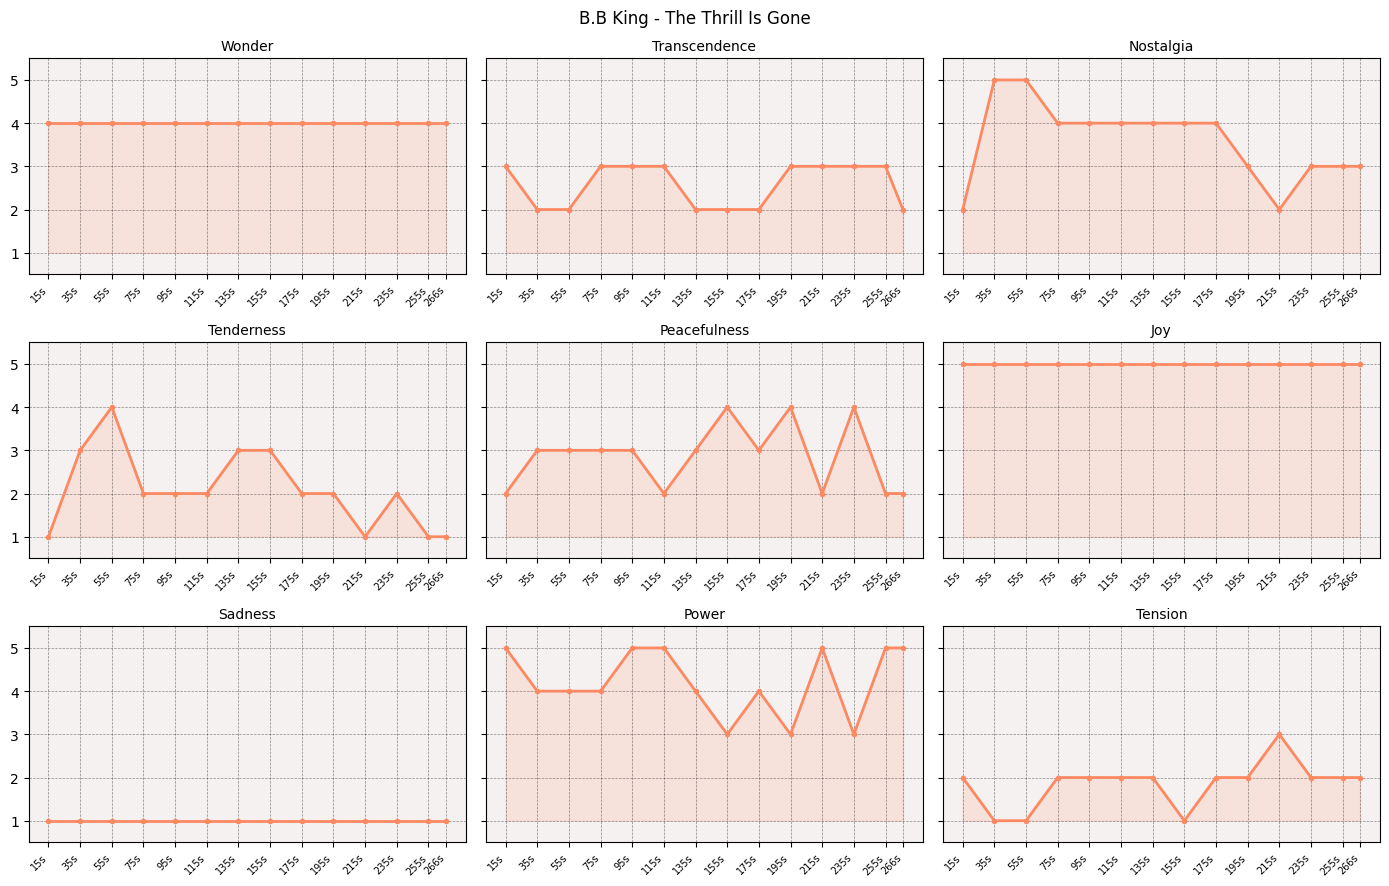

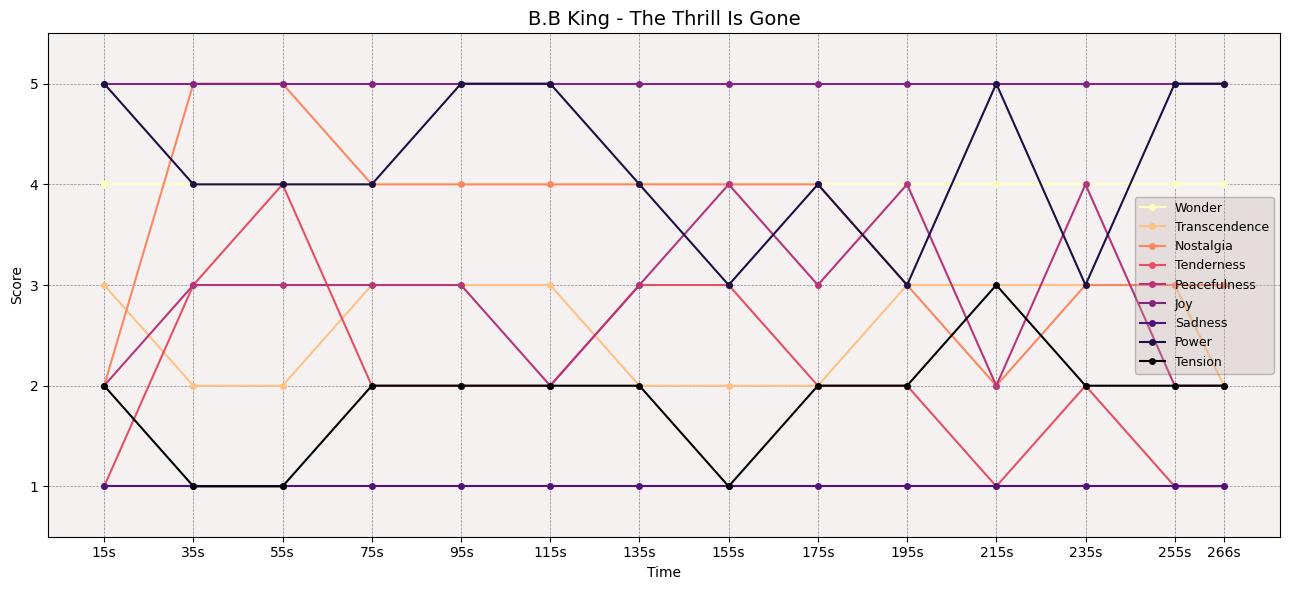

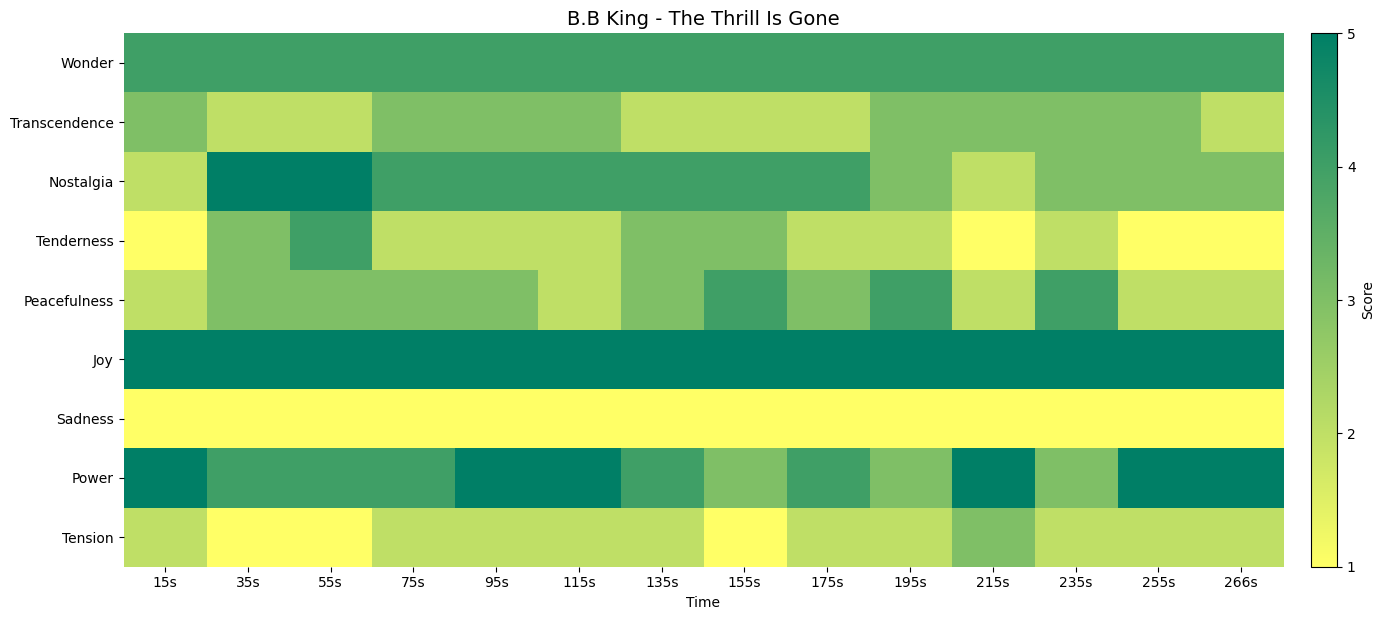

In [128]:
BBKing_seg_track = """
[B.B King - The Thrill Is Gone] [0.0s – 30.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[B.B King - The Thrill Is Gone] [20.0s – 50.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 5
- Tenderness: 3
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 1

[B.B King - The Thrill Is Gone] [40.0s – 70.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 5
- Tenderness: 4
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 1

[B.B King - The Thrill Is Gone] [60.0s – 90.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 2
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[B.B King - The Thrill Is Gone] [80.0s – 110.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 2
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[B.B King - The Thrill Is Gone] [100.0s – 130.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[B.B King - The Thrill Is Gone] [120.0s – 150.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 4
- Tenderness: 3
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[B.B King - The Thrill Is Gone] [140.0s – 170.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 4
- Tenderness: 3
- Peacefulness: 4
- Joy: 5
- Sadness: 1
- Power: 3
- Tension: 1

[B.B King - The Thrill Is Gone] [160.0s – 190.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 4
- Tenderness: 2
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[B.B King - The Thrill Is Gone] [180.0s – 210.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 4
- Joy: 5
- Sadness: 1
- Power: 3
- Tension: 2

[B.B King - The Thrill Is Gone] [200.0s – 230.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 3

[B.B King - The Thrill Is Gone] [220.0s – 250.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 4
- Joy: 5
- Sadness: 1
- Power: 3
- Tension: 2

[B.B King - The Thrill Is Gone] [240.0s – 270.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 3
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[B.B King - The Thrill Is Gone] [260.0s – 272.1s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 3
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2"""

track, emotions, time_labels = parse_emotion_data(BBKing_seg_track)
plot_emotions(track, emotions, time_labels)
plot_all_emotions(track, emotions, time_labels)
heatmap_emotions(track, emotions, time_labels)

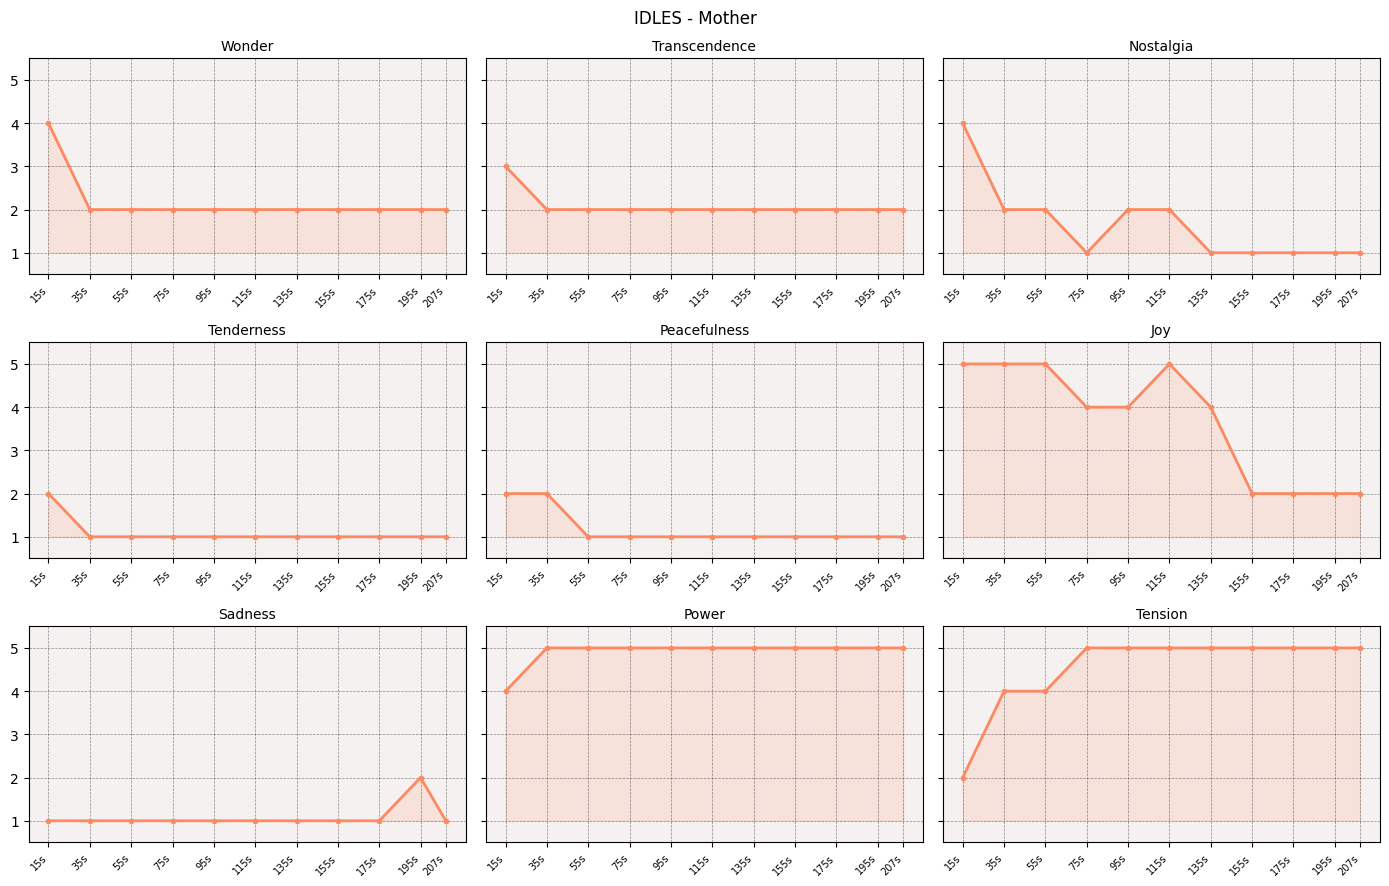

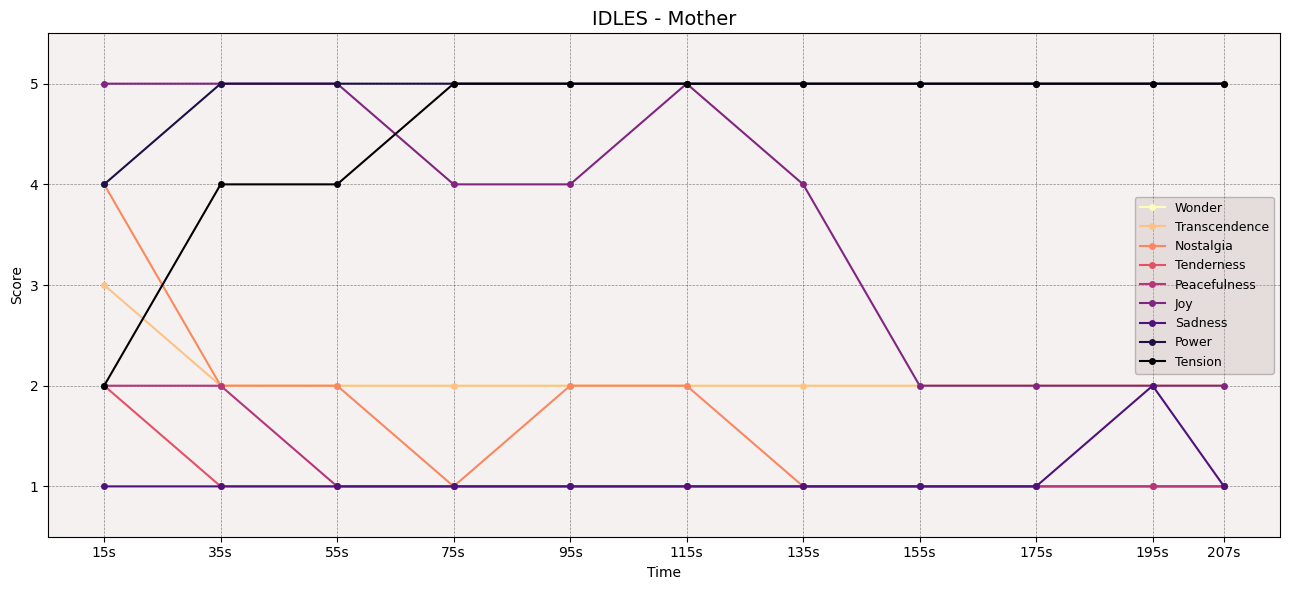

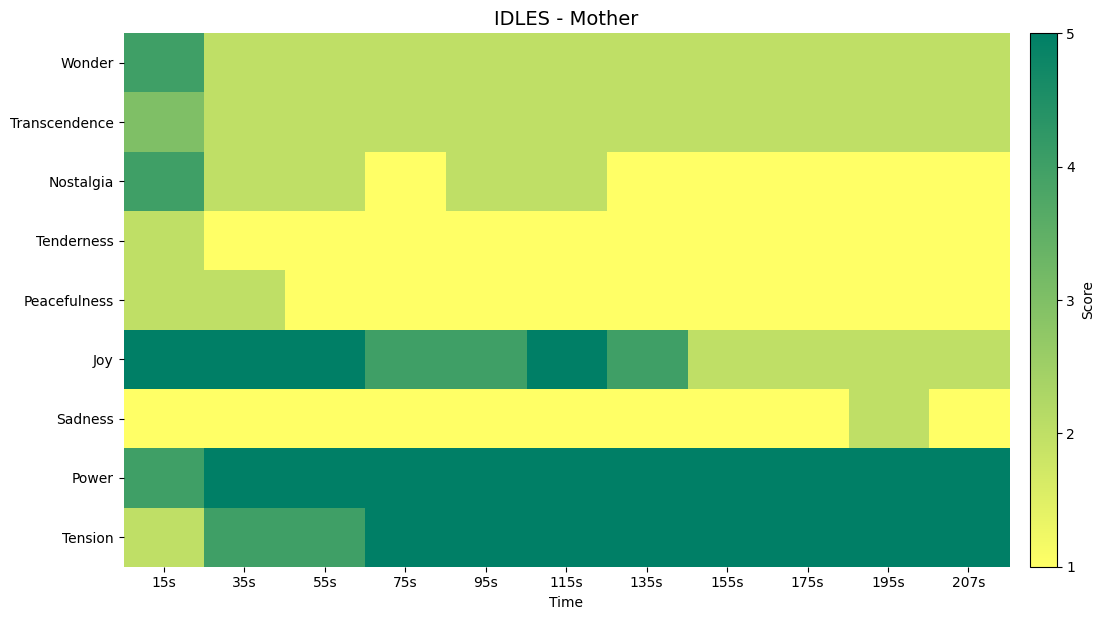

In [129]:
Idles_seg_track = """
[IDLES - Mother] [0.0s – 30.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[IDLES - Mother] [20.0s – 50.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 4

[IDLES - Mother] [40.0s – 70.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 1
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 4

[IDLES - Mother] [60.0s – 90.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 1
- Joy: 4
- Sadness: 1
- Power: 5
- Tension: 5

[IDLES - Mother] [80.0s – 110.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 1
- Joy: 4
- Sadness: 1
- Power: 5
- Tension: 5

[IDLES - Mother] [100.0s – 130.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 1
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 5

[IDLES - Mother] [120.0s – 150.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 1
- Joy: 4
- Sadness: 1
- Power: 5
- Tension: 5

[IDLES - Mother] [140.0s – 170.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 1
- Joy: 2
- Sadness: 1
- Power: 5
- Tension: 5

[IDLES - Mother] [160.0s – 190.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 1
- Joy: 2
- Sadness: 1
- Power: 5
- Tension: 5

[IDLES - Mother] [180.0s – 210.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 1
- Joy: 2
- Sadness: 2
- Power: 5
- Tension: 5

[IDLES - Mother] [200.0s – 214.5s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 1
- Joy: 2
- Sadness: 1
- Power: 5
- Tension: 5"""

track, emotions, time_labels = parse_emotion_data(Idles_seg_track)
plot_emotions(track, emotions, time_labels)
plot_all_emotions(track, emotions, time_labels)
heatmap_emotions(track, emotions, time_labels)

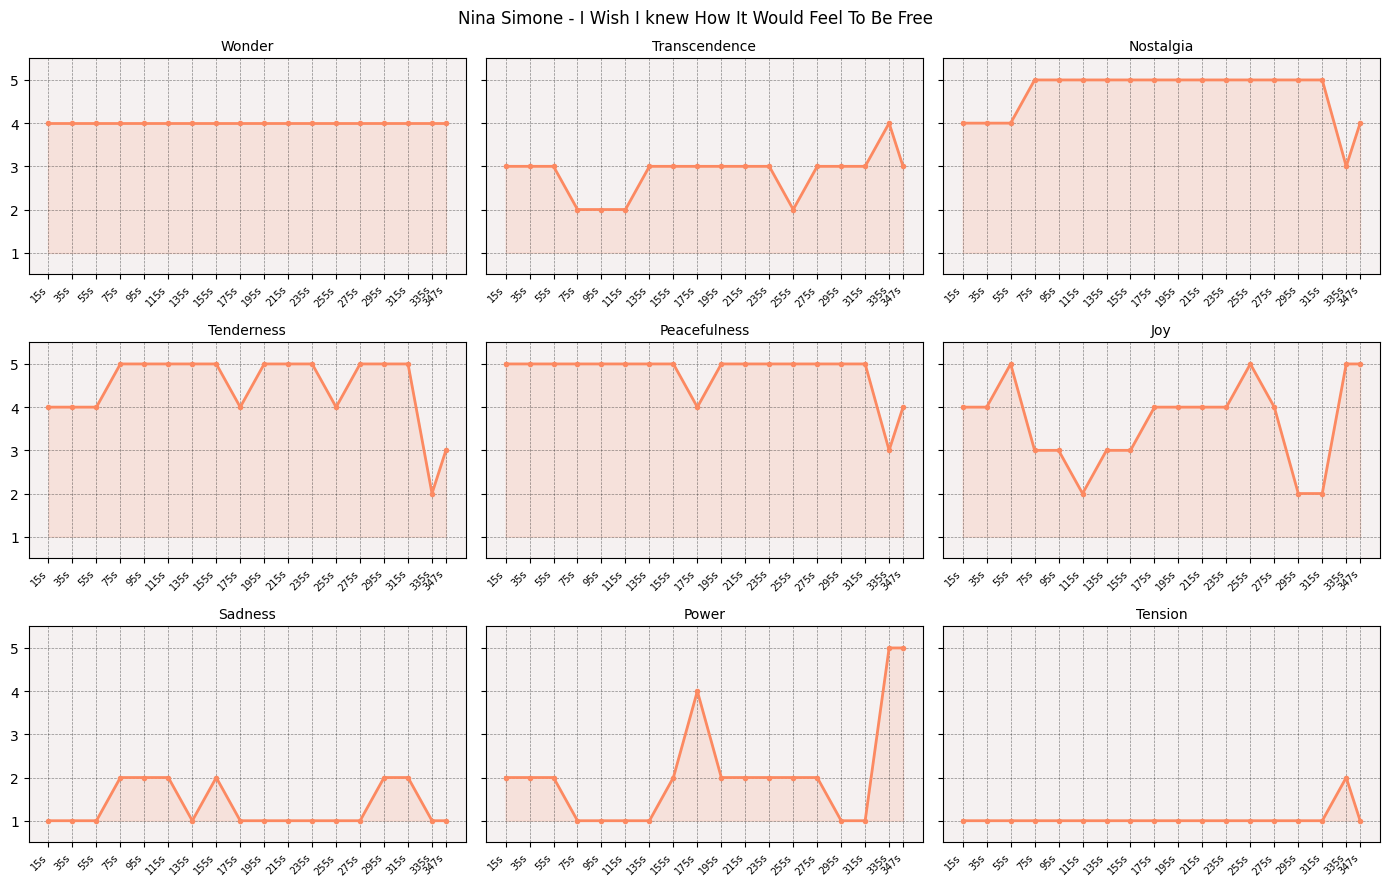

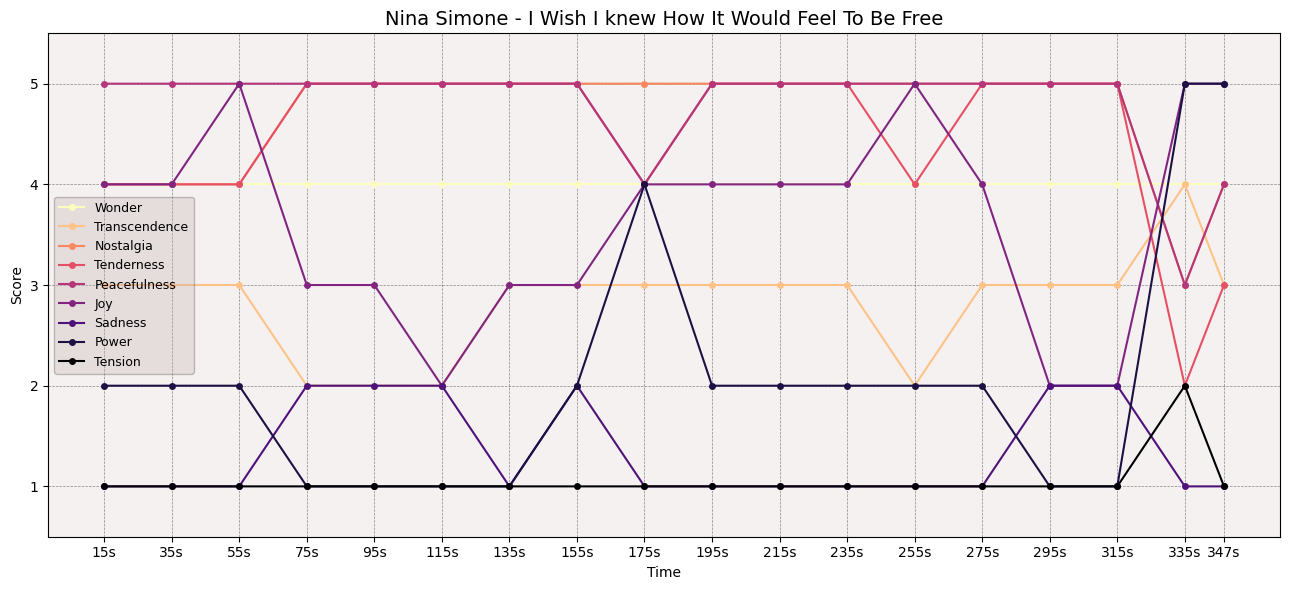

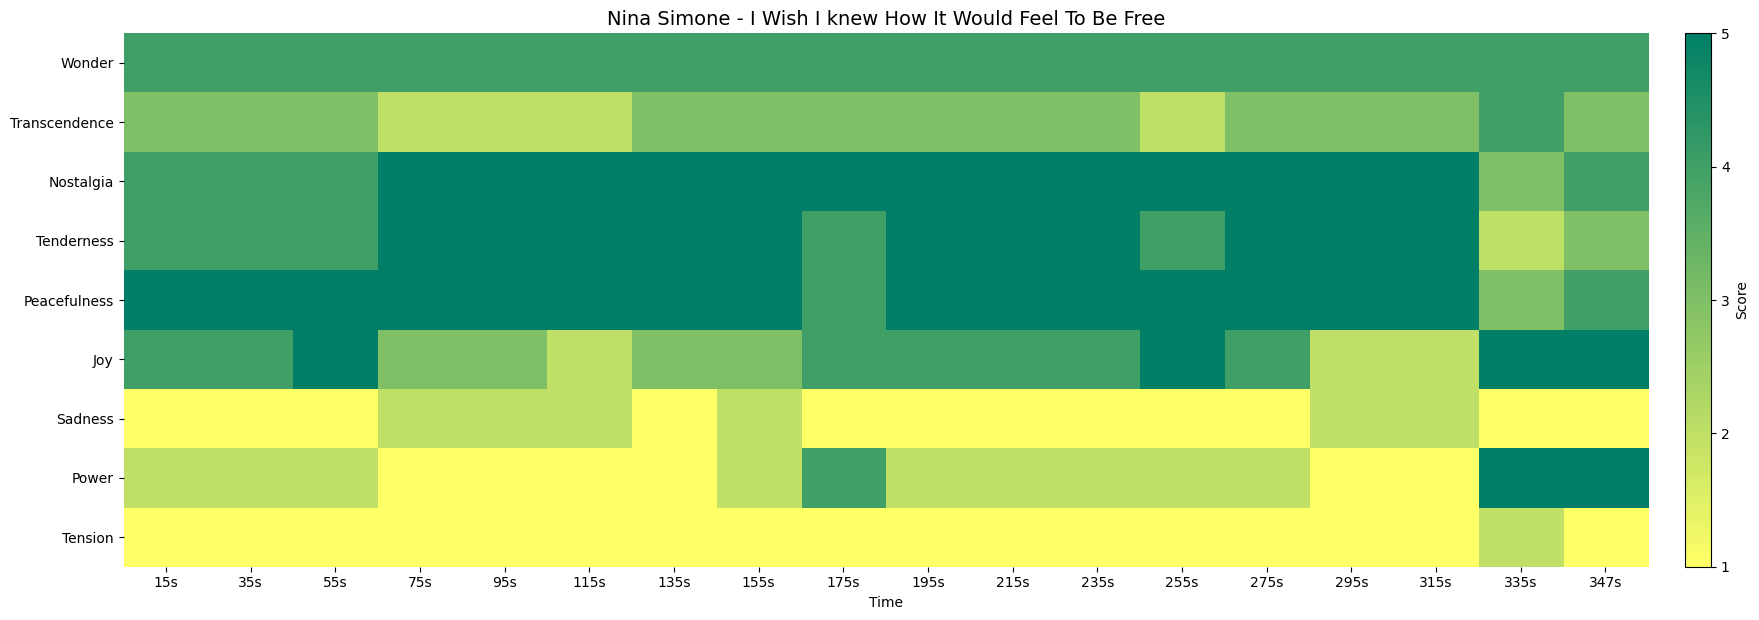

In [130]:
Simone_seg_track = """
[Nina Simone - I Wish I knew How It Would Feel To Be Free] [0.0s – 30.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 4
- Peacefulness: 5
- Joy: 4
- Sadness: 1
- Power: 2
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [20.0s – 50.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 4
- Peacefulness: 5
- Joy: 4
- Sadness: 1
- Power: 2
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [40.0s – 70.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 4
- Peacefulness: 5
- Joy: 5
- Sadness: 1
- Power: 2
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [60.0s – 90.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 3
- Sadness: 2
- Power: 1
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [80.0s – 110.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 3
- Sadness: 2
- Power: 1
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [100.0s – 130.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 2
- Power: 1
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [120.0s – 150.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 3
- Sadness: 1
- Power: 1
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [140.0s – 170.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 3
- Sadness: 2
- Power: 2
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [160.0s – 190.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 4
- Peacefulness: 4
- Joy: 4
- Sadness: 1
- Power: 4
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [180.0s – 210.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 4
- Sadness: 1
- Power: 2
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [200.0s – 230.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 4
- Sadness: 1
- Power: 2
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [220.0s – 250.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 4
- Sadness: 1
- Power: 2
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [240.0s – 270.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 5
- Tenderness: 4
- Peacefulness: 5
- Joy: 5
- Sadness: 1
- Power: 2
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [260.0s – 290.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 4
- Sadness: 1
- Power: 2
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [280.0s – 310.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 2
- Power: 1
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [300.0s – 330.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 2
- Power: 1
- Tension: 1

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [320.0s – 350.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[Nina Simone - I Wish I knew How It Would Feel To Be Free] [340.0s – 353.2s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 3
- Peacefulness: 4
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 1"""

track, emotions, time_labels = parse_emotion_data(Simone_seg_track)
plot_emotions(track, emotions, time_labels)
plot_all_emotions(track, emotions, time_labels)
heatmap_emotions(track, emotions, time_labels)

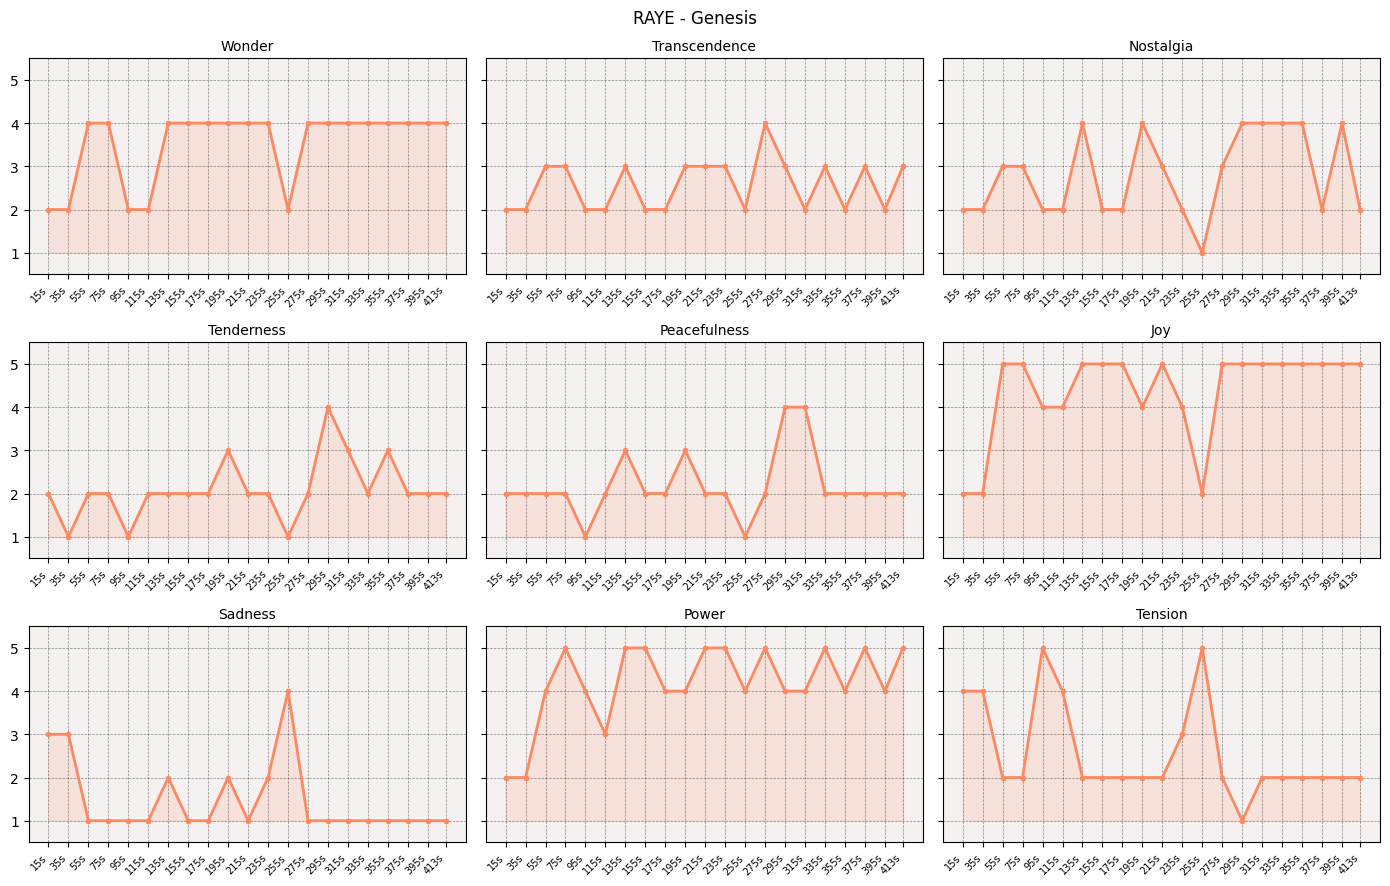

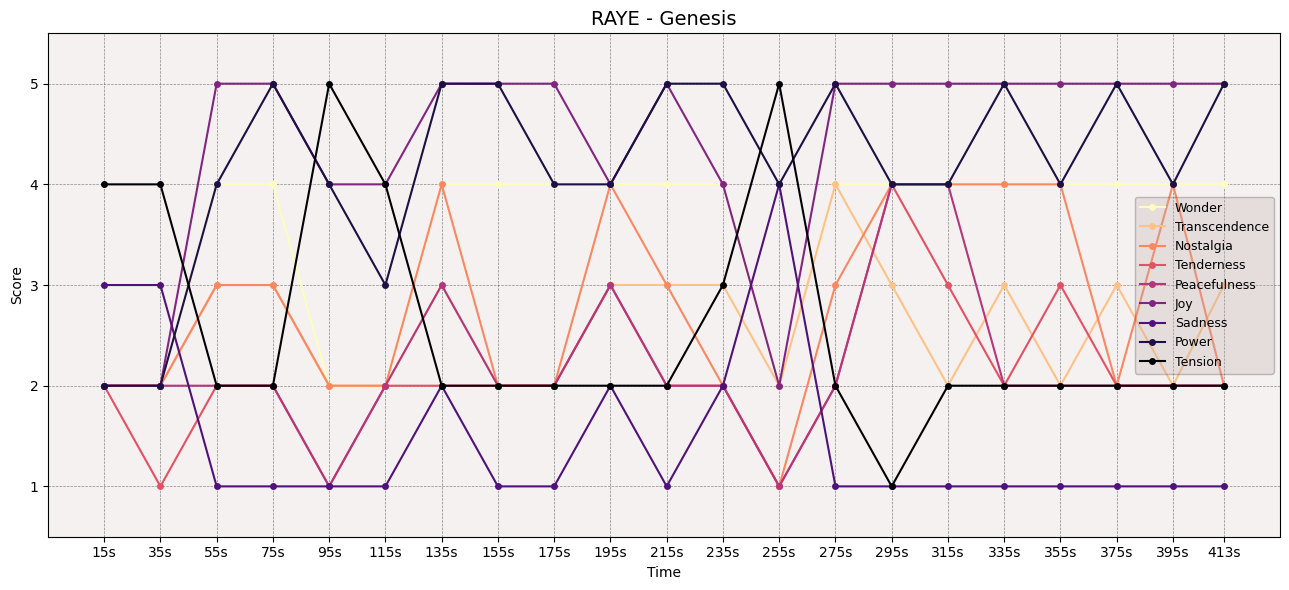

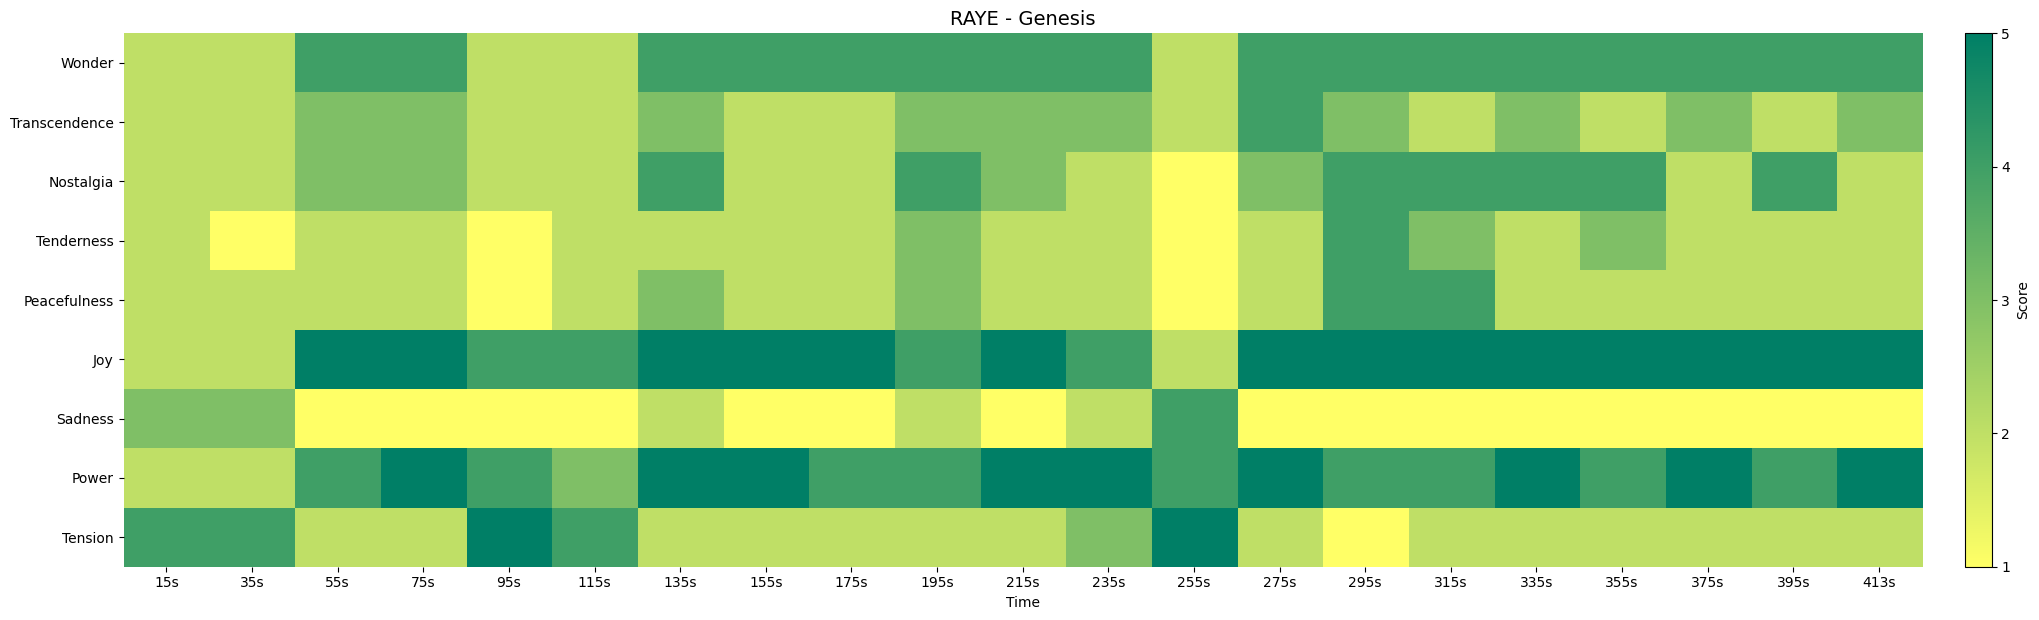

In [131]:
Raye_seg_track = """
[RAYE - Genesis] [0.0s – 30.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 2
- Peacefulness: 2
- Joy: 2
- Sadness: 3
- Power: 2
- Tension: 4

[RAYE - Genesis] [20.0s – 50.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 2
- Joy: 2
- Sadness: 3
- Power: 2
- Tension: 4

[RAYE - Genesis] [40.0s – 70.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[RAYE - Genesis] [60.0s – 90.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[RAYE - Genesis] [80.0s – 110.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 1
- Joy: 4
- Sadness: 1
- Power: 4
- Tension: 5

[RAYE - Genesis] [100.0s – 130.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 2
- Peacefulness: 2
- Joy: 4
- Sadness: 1
- Power: 3
- Tension: 4

[RAYE - Genesis] [120.0s – 150.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 2
- Peacefulness: 3
- Joy: 5
- Sadness: 2
- Power: 5
- Tension: 2

[RAYE - Genesis] [140.0s – 170.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[RAYE - Genesis] [160.0s – 190.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[RAYE - Genesis] [180.0s – 210.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 3
- Peacefulness: 3
- Joy: 4
- Sadness: 2
- Power: 4
- Tension: 2

[RAYE - Genesis] [200.0s – 230.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[RAYE - Genesis] [220.0s – 250.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 2
- Tenderness: 2
- Peacefulness: 2
- Joy: 4
- Sadness: 2
- Power: 5
- Tension: 3

[RAYE - Genesis] [240.0s – 270.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 1
- Joy: 2
- Sadness: 4
- Power: 4
- Tension: 5

[RAYE - Genesis] [260.0s – 290.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[RAYE - Genesis] [280.0s – 310.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 4
- Peacefulness: 4
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 1

[RAYE - Genesis] [300.0s – 330.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 4
- Tenderness: 3
- Peacefulness: 4
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[RAYE - Genesis] [320.0s – 350.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[RAYE - Genesis] [340.0s – 370.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 4
- Tenderness: 3
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[RAYE - Genesis] [360.0s – 390.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 2
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[RAYE - Genesis] [380.0s – 410.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 4
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[RAYE - Genesis] [400.0s – 426.3s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 2
- Tenderness: 2
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2"""

track, emotions, time_labels = parse_emotion_data(Raye_seg_track)
plot_emotions(track, emotions, time_labels)
plot_all_emotions(track, emotions, time_labels)
heatmap_emotions(track, emotions, time_labels)

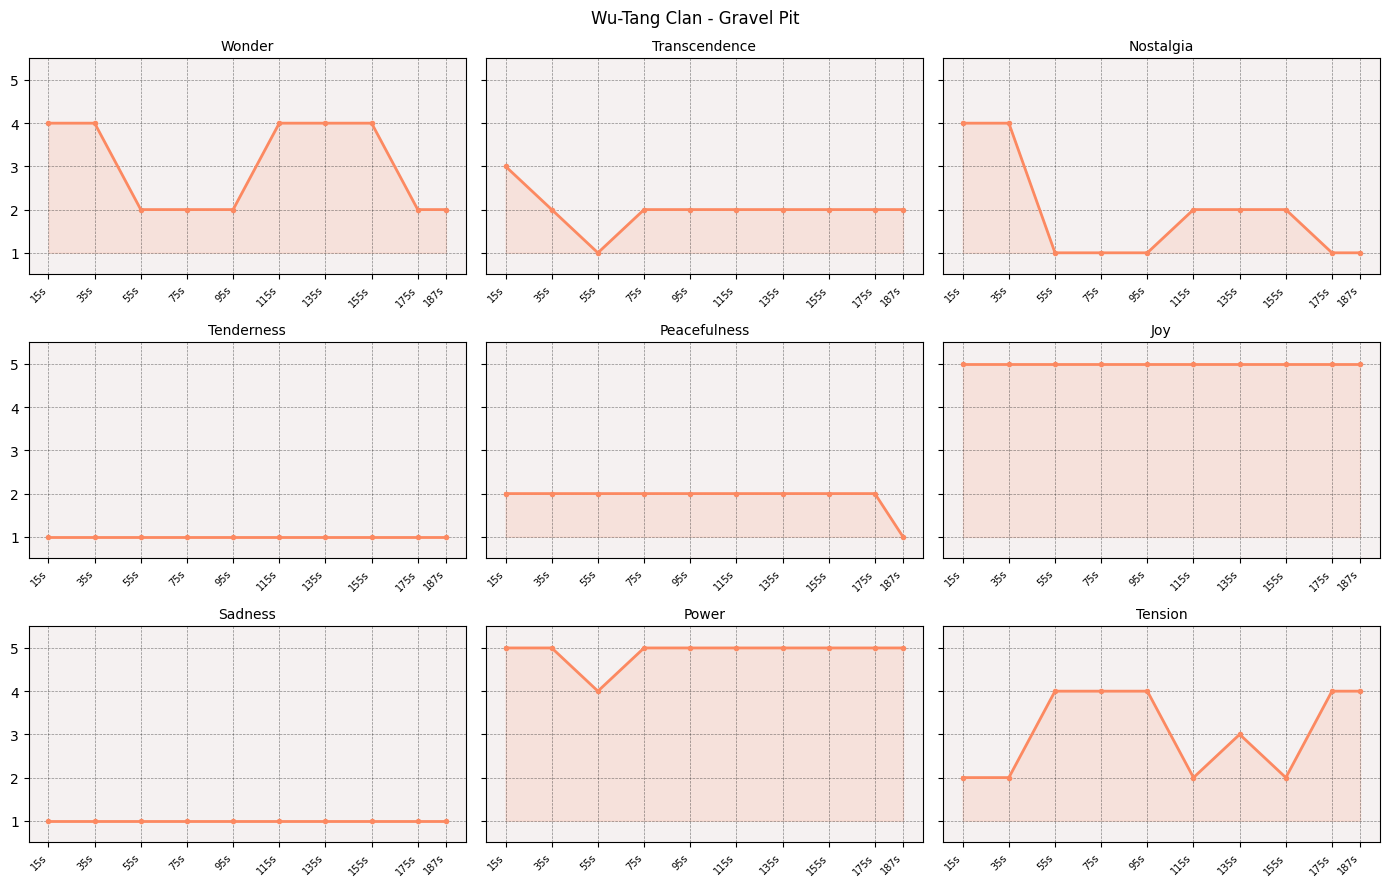

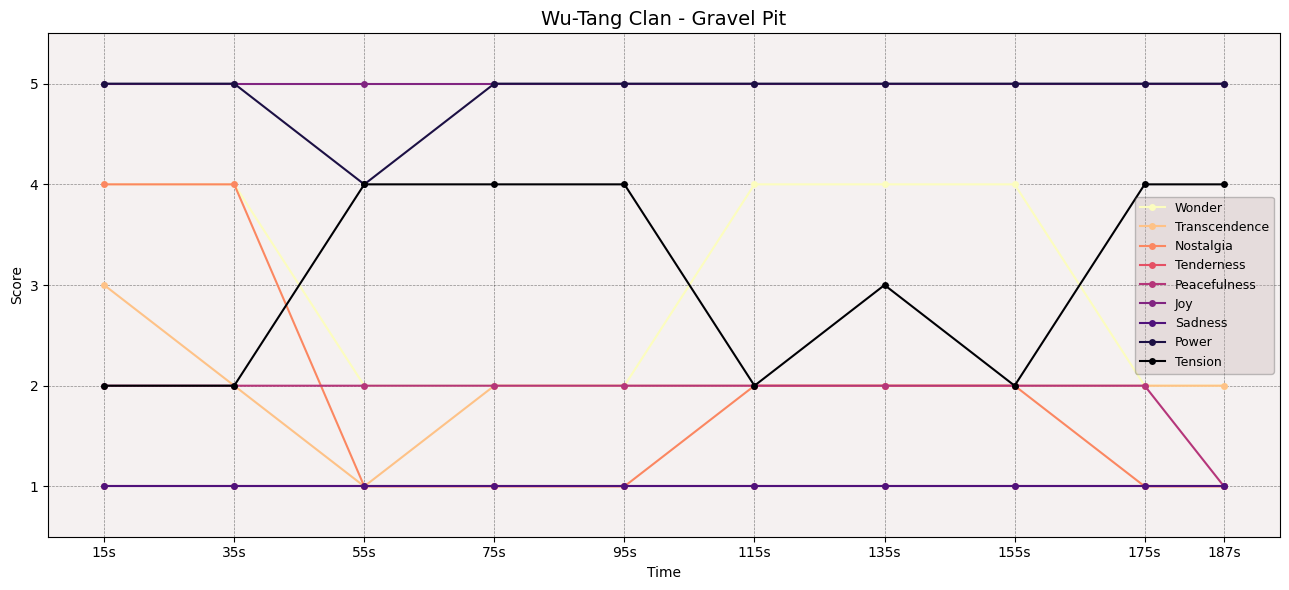

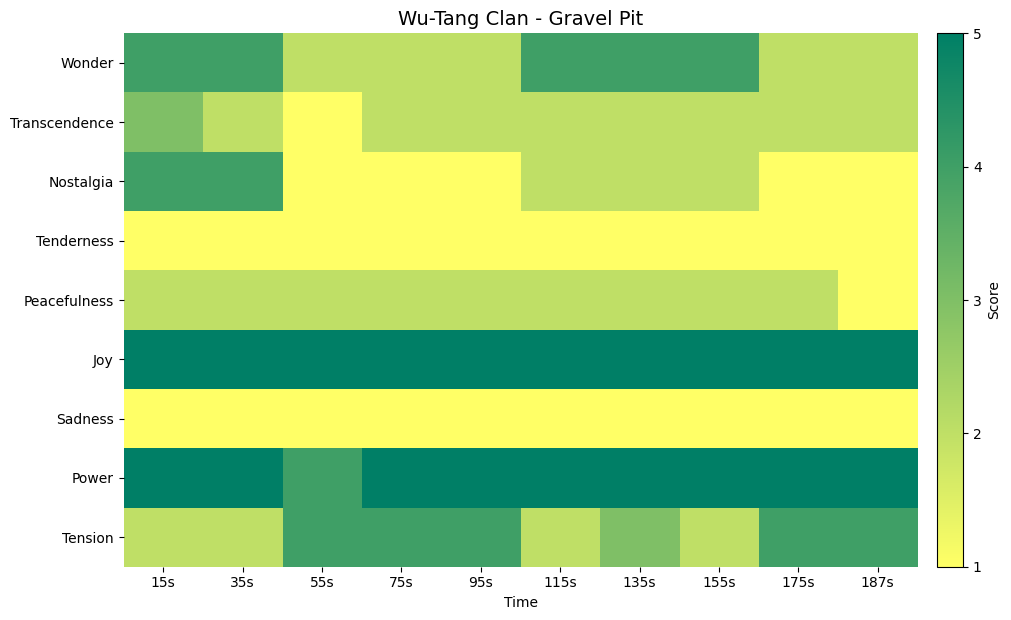

In [132]:
Wu_Tang_seg_track = """
[Wu-Tang Clan - Gravel Pit] [0.0s – 30.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[Wu-Tang Clan - Gravel Pit] [20.0s – 50.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 4
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[Wu-Tang Clan - Gravel Pit] [40.0s – 70.0s]
- Wonder: 2
- Transcendence: 1
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 4

[Wu-Tang Clan - Gravel Pit] [60.0s – 90.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 4

[Wu-Tang Clan - Gravel Pit] [80.0s – 110.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 4

[Wu-Tang Clan - Gravel Pit] [100.0s – 130.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[Wu-Tang Clan - Gravel Pit] [120.0s – 150.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 3

[Wu-Tang Clan - Gravel Pit] [140.0s – 170.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 2
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[Wu-Tang Clan - Gravel Pit] [160.0s – 190.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 2
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 4

[Wu-Tang Clan - Gravel Pit] [180.0s – 194.4s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 1
- Tenderness: 1
- Peacefulness: 1
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 4
"""

track, emotions, time_labels = parse_emotion_data(Wu_Tang_seg_track)
plot_emotions(track, emotions, time_labels)
plot_all_emotions(track, emotions, time_labels)
heatmap_emotions(track, emotions, time_labels)

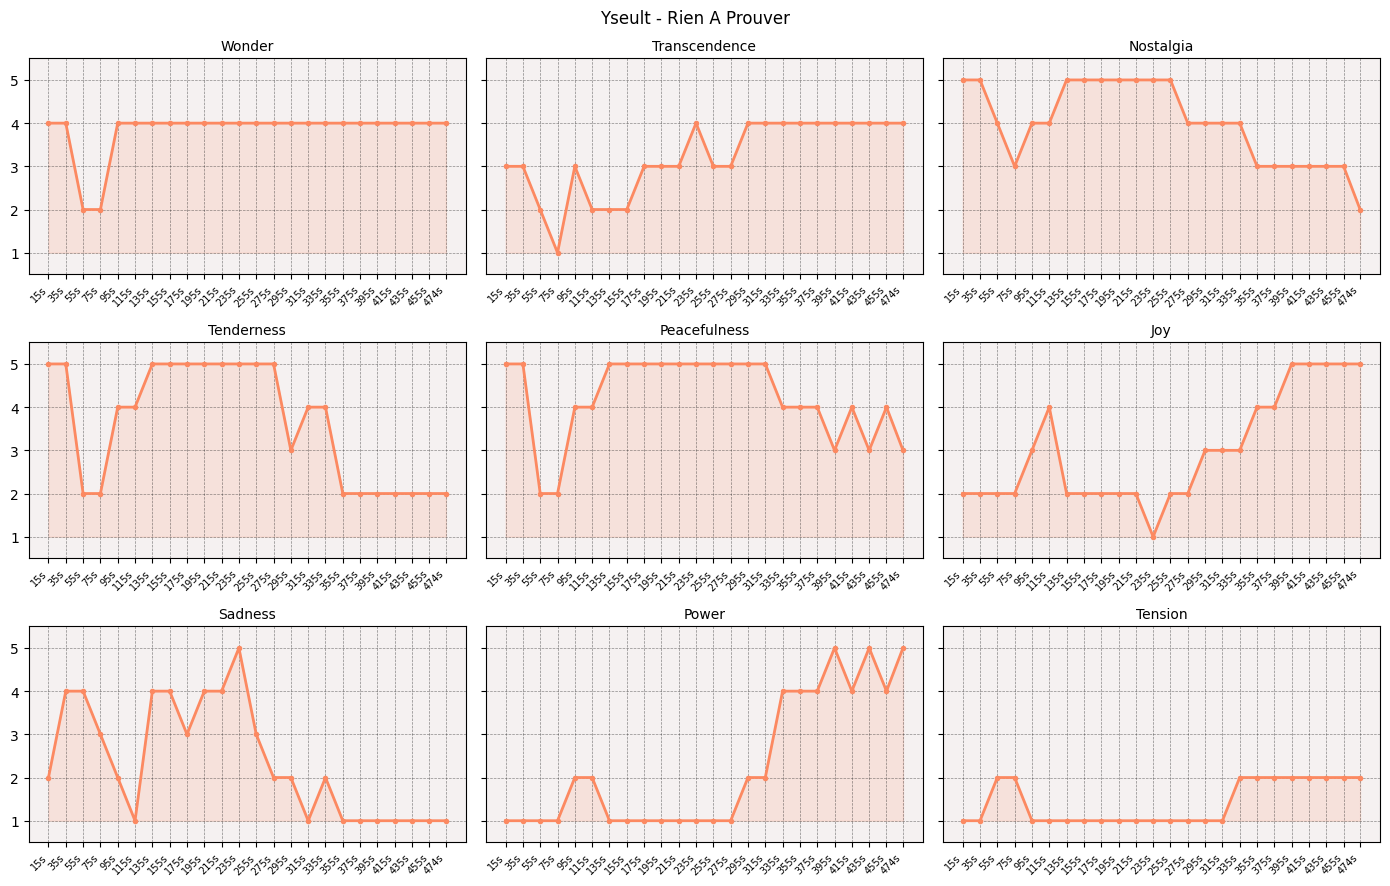

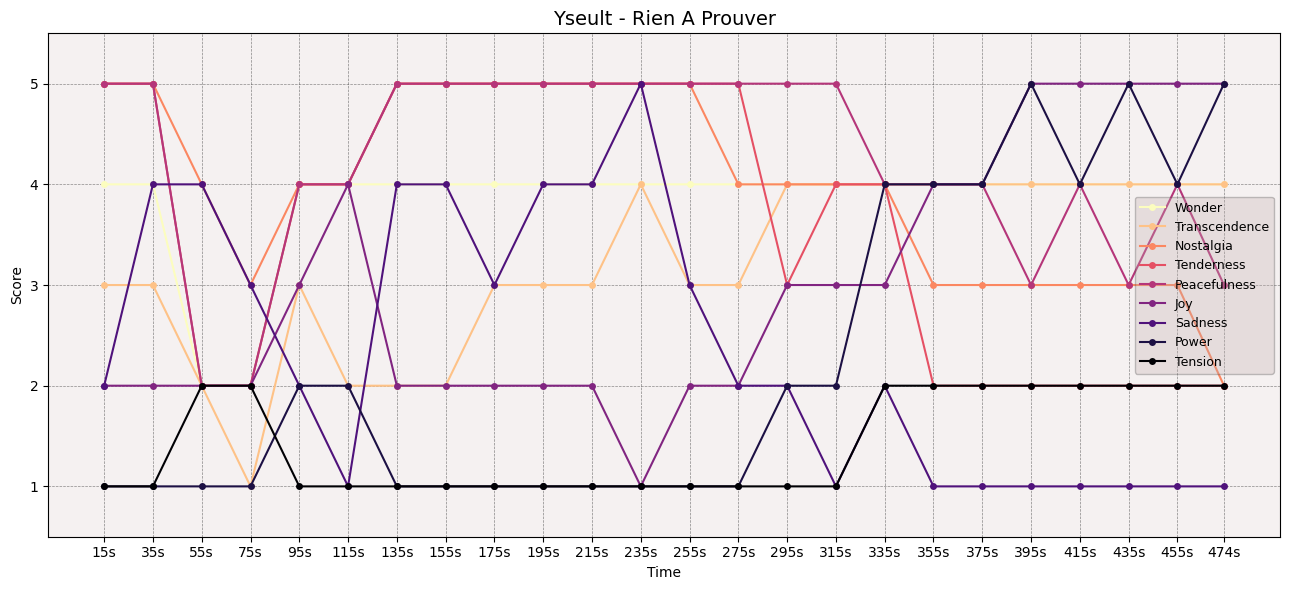

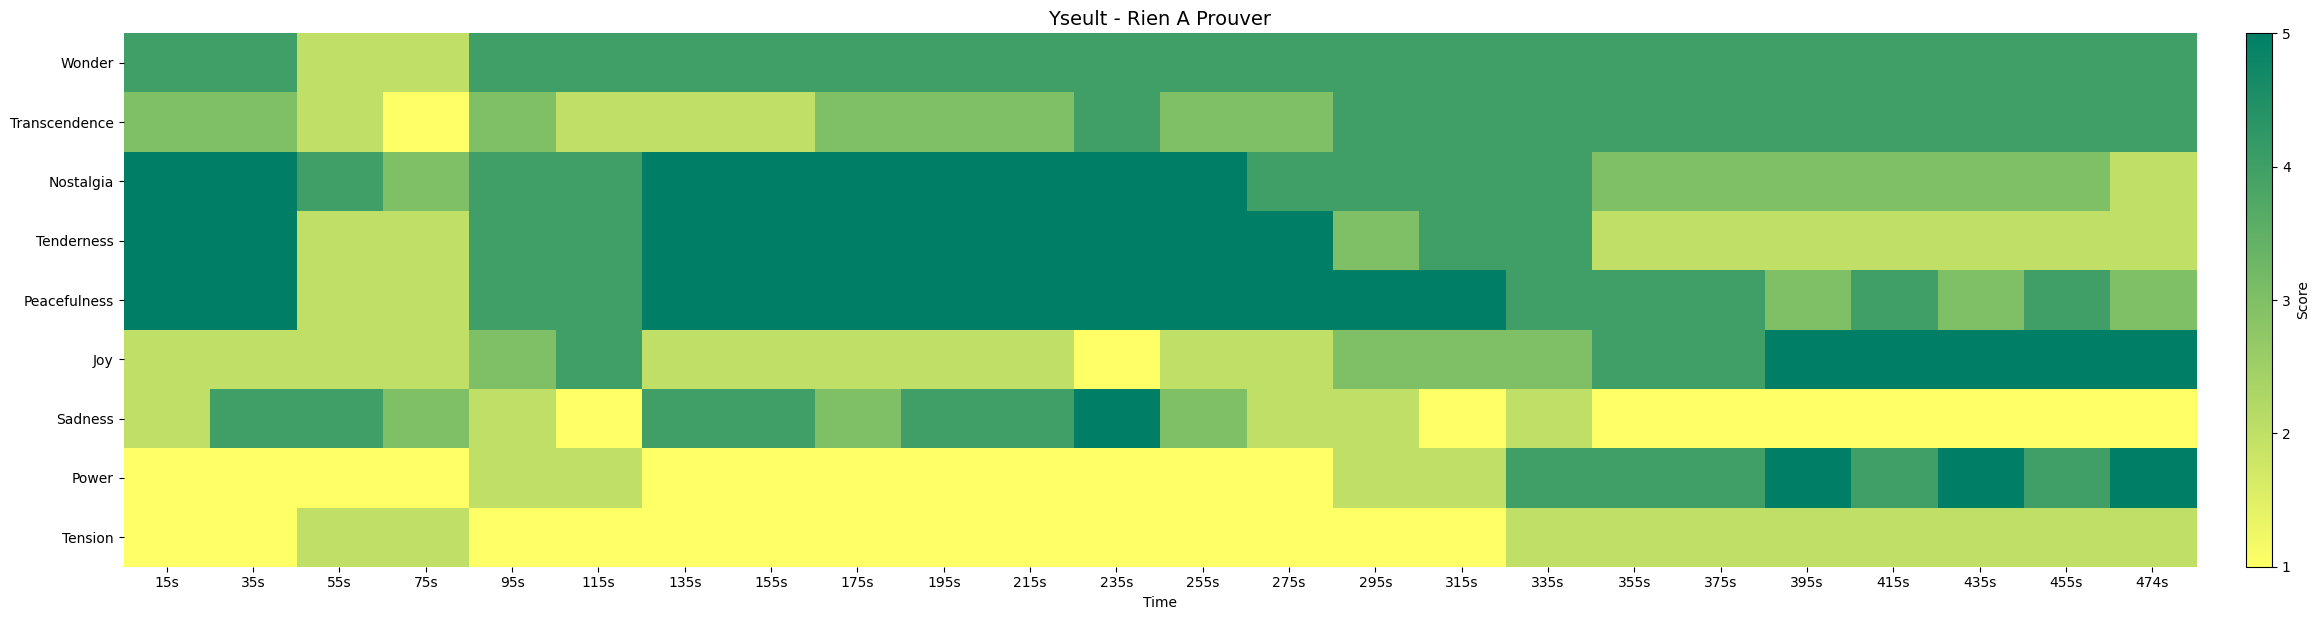

In [133]:
Yseult_seg_track = """
[Yseult - Rien A Prouver] [0.0s – 30.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 2
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [20.0s – 50.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 4
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [40.0s – 70.0s]
- Wonder: 2
- Transcendence: 2
- Nostalgia: 4
- Tenderness: 2
- Peacefulness: 2
- Joy: 2
- Sadness: 4
- Power: 1
- Tension: 2

[Yseult - Rien A Prouver] [60.0s – 90.0s]
- Wonder: 2
- Transcendence: 1
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 2
- Joy: 2
- Sadness: 3
- Power: 1
- Tension: 2

[Yseult - Rien A Prouver] [80.0s – 110.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 4
- Peacefulness: 4
- Joy: 3
- Sadness: 2
- Power: 2
- Tension: 1

[Yseult - Rien A Prouver] [100.0s – 130.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 4
- Tenderness: 4
- Peacefulness: 4
- Joy: 4
- Sadness: 1
- Power: 2
- Tension: 1

[Yseult - Rien A Prouver] [120.0s – 150.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 4
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [140.0s – 170.0s]
- Wonder: 4
- Transcendence: 2
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 4
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [160.0s – 190.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 3
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [180.0s – 210.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 4
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [200.0s – 230.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 4
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [220.0s – 250.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 1
- Sadness: 5
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [240.0s – 270.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 5
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 3
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [260.0s – 290.0s]
- Wonder: 4
- Transcendence: 3
- Nostalgia: 4
- Tenderness: 5
- Peacefulness: 5
- Joy: 2
- Sadness: 2
- Power: 1
- Tension: 1

[Yseult - Rien A Prouver] [280.0s – 310.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 4
- Tenderness: 3
- Peacefulness: 5
- Joy: 3
- Sadness: 2
- Power: 2
- Tension: 1

[Yseult - Rien A Prouver] [300.0s – 330.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 4
- Tenderness: 4
- Peacefulness: 5
- Joy: 3
- Sadness: 1
- Power: 2
- Tension: 1

[Yseult - Rien A Prouver] [320.0s – 350.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 4
- Tenderness: 4
- Peacefulness: 4
- Joy: 3
- Sadness: 2
- Power: 4
- Tension: 2

[Yseult - Rien A Prouver] [340.0s – 370.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 4
- Joy: 4
- Sadness: 1
- Power: 4
- Tension: 2

[Yseult - Rien A Prouver] [360.0s – 390.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 4
- Joy: 4
- Sadness: 1
- Power: 4
- Tension: 2

[Yseult - Rien A Prouver] [380.0s – 410.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[Yseult - Rien A Prouver] [400.0s – 430.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 4
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[Yseult - Rien A Prouver] [420.0s – 450.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2

[Yseult - Rien A Prouver] [440.0s – 470.0s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 3
- Tenderness: 2
- Peacefulness: 4
- Joy: 5
- Sadness: 1
- Power: 4
- Tension: 2

[Yseult - Rien A Prouver] [460.0s – 488.2s]
- Wonder: 4
- Transcendence: 4
- Nostalgia: 2
- Tenderness: 2
- Peacefulness: 3
- Joy: 5
- Sadness: 1
- Power: 5
- Tension: 2"""

track, emotions, time_labels = parse_emotion_data(Yseult_seg_track)
plot_emotions(track, emotions, time_labels)
plot_all_emotions(track, emotions, time_labels)
heatmap_emotions(track, emotions, time_labels)